In [1]:
import pandas as pd
from datetime import date, timedelta
import missingno as msno
import plotly.express as px
import sys
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
import pickle

rpy2.ipython.html.init_printing()

import random
import geopandas as gpd
import numpy as np

import sys

sys.path.insert(0, "../../utils")

from plots import *
from string_handling import *
from modules import *

enc = 'utf-8' 

random.seed(0)
np.random.seed(0)

pd.set_option('display.max_columns', None)

c:\Users\dimit\Python Virtual Environments\noa_eywa\Lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [2]:
utils = importr('utils')
base = importr('base')
dismo = importr('dismo')
utils.chooseCRANmirror(ind=41)

<rpy2.rinterface_lib.sexp.NULLType object at 0x0000027A79F2A490> [0]

In [3]:
REGION = 'Nord'
YEAR = 2024

In [4]:
# timeline_file = pd.read_csv(f'../../data/{REGION}/CM_{REGION}_Timeline_{YEAR}_filled_cleaned.csv', encoding=enc)

In [4]:
timeline_file = pd.read_csv(f'../../data/{REGION}/CM_{REGION}_Timeline_{YEAR}_filled_cleaned.csv', encoding=enc)

In [5]:
try:
    timeline_file.drop(['Unnamed: 0'], axis=1, inplace=True)
except KeyError:
    print("Column 'Unnamed: 0' not found in the DataFrame.")

In [6]:
timeline_file

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall
0,12.29306,8.21972,nord,faro,poli,balkossa,2024-01-01,2024,1,0.234069,-0.153430,-0.298374,0.153430,0.254741,-0.141299,-0.300685,0.141299,0.024187,0.032594,0.012017,0.032594,15247.0,14544.0,0.0
1,12.29306,8.21972,nord,faro,poli,balkossa,2024-01-02,2024,1,0.234069,-0.153430,-0.298374,0.153430,0.254741,-0.141299,-0.300685,0.141299,0.024187,0.032594,0.012017,0.032594,15410.0,14544.0,0.0
2,12.29306,8.21972,nord,faro,poli,balkossa,2024-01-03,2024,1,0.234069,-0.153430,-0.298374,0.153430,0.254741,-0.141299,-0.300685,0.141299,0.024187,0.032594,0.012017,0.032594,15410.0,14575.0,0.0
3,12.29306,8.21972,nord,faro,poli,balkossa,2024-01-04,2024,1,0.234069,-0.153430,-0.298374,0.153430,0.254741,-0.141299,-0.300685,0.141299,0.024187,0.032594,0.012017,0.032594,15417.0,14521.0,0.0
4,12.29306,8.21972,nord,faro,poli,balkossa,2024-01-05,2024,1,0.364624,-0.014147,-0.393515,0.014147,0.319521,-0.053684,-0.406543,0.053684,0.035530,0.029277,0.015771,0.029277,15451.0,14521.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1448989,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2024-12-27,2024,12,0.254978,-0.129234,-0.289343,0.129234,0.295193,-0.097900,-0.305340,0.097900,0.086505,0.056897,0.051174,0.056897,15085.0,14441.0,0.0
1448990,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2024-12-28,2024,12,0.254978,-0.129234,-0.289343,0.129234,0.295193,-0.097900,-0.305340,0.097900,0.086505,0.056897,0.051174,0.056897,15085.0,14476.0,0.0
1448991,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2024-12-29,2024,12,0.254978,-0.129234,-0.289343,0.129234,0.295193,-0.097900,-0.305340,0.097900,0.086505,0.056897,0.051174,0.056897,15052.0,14453.0,0.0
1448992,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2024-12-30,2024,12,0.243278,-0.137847,-0.282271,0.137847,0.280358,-0.107628,-0.296999,0.107628,0.080038,0.052339,0.048076,0.052339,15157.0,14453.0,0.0


In [7]:
timeline_file.describe()

,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall
count,1.448994e+06,1.448994e+06,1448994.0,1.448994e+06,1.095370e+06,1.095332e+06,1.095370e+06,1.095332e+06,1.148670e+06,1.148644e+06,1.148675e+06,1.148526e+06,1.148670e+06,1.148644e+06,1.148675e+06,1.148526e+06,1.210388e+06,1.128187e+06,1.448994e+06
mean,1.394363e+01,8.485321e+00,2024.0,6.513661e+00,3.581476e-01,1.202819e-02,-3.306250e-01,-1.202819e-02,3.585945e-01,1.781550e-02,-3.293775e-01,-1.780306e-02,2.773458e-02,2.652124e-02,2.291406e-02,2.652170e-02,1.526080e+04,1.472632e+04,6.830673e+00
std,7.548784e-01,7.046535e-01,0.0,3.451235e+00,1.864587e-01,1.697383e-01,1.259408e-01,1.697383e-01,1.813314e-01,1.670733e-01,1.213742e-01,1.670569e-01,2.547026e-02,2.137359e-02,2.538539e-02,2.137368e-02,2.796416e+02,1.764060e+02,1.542978e+01
min,1.229306e+01,7.069850e+00,2024.0,1.000000e+00,-5.227538e-01,-5.040811e-01,-1.034871e+00,-8.434343e-01,-5.147782e-01,-3.051389e-01,-1.034871e+00,-8.516978e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.364500e+04,1.389900e+04,0.000000e+00
25%,1.334299e+01,7.968190e+00,2024.0,4.000000e+00,2.027175e-01,-1.296534e-01,-4.194541e-01,-1.531935e-01,2.048286e-01,-1.240755e-01,-4.177519e-01,-1.620172e-01,1.313826e-02,1.355995e-02,1.050753e-02,1.355995e-02,1.505700e+04,1.459600e+04,0.000000e+00
50%,1.392226e+01,8.399390e+00,2024.0,7.000000e+00,3.346056e-01,-2.762991e-02,-3.387675e-01,2.762991e-02,3.398973e-01,-1.801962e-02,-3.378214e-01,1.804864e-02,2.170876e-02,2.170435e-02,1.682533e-02,2.170445e-02,1.520900e+04,1.473200e+04,6.000000e-02
75%,1.453774e+01,8.974320e+00,2024.0,1.000000e+01,5.262136e-01,1.531935e-01,-2.546365e-01,1.296534e-01,5.231304e-01,1.620189e-01,-2.528550e-01,1.240755e-01,3.461445e-02,3.364002e-02,2.697739e-02,3.364059e-02,1.546100e+04,1.484400e+04,5.630000e+00
max,1.555146e+01,1.023199e+01,2024.0,1.200000e+01,7.881458e-01,8.434343e-01,8.792041e-01,5.040811e-01,7.856284e-01,8.516978e-01,8.706722e-01,3.051389e-01,4.334157e-01,5.977011e-01,5.359307e-01,5.977011e-01,1.665700e+04,1.548500e+04,2.942800e+02


In [8]:
print(f'Shape of the timeline file: {timeline_file.shape}')

Shape of the timeline file: (1448994, 24)


Text(0.5, 1.0, 'Year: 2024')

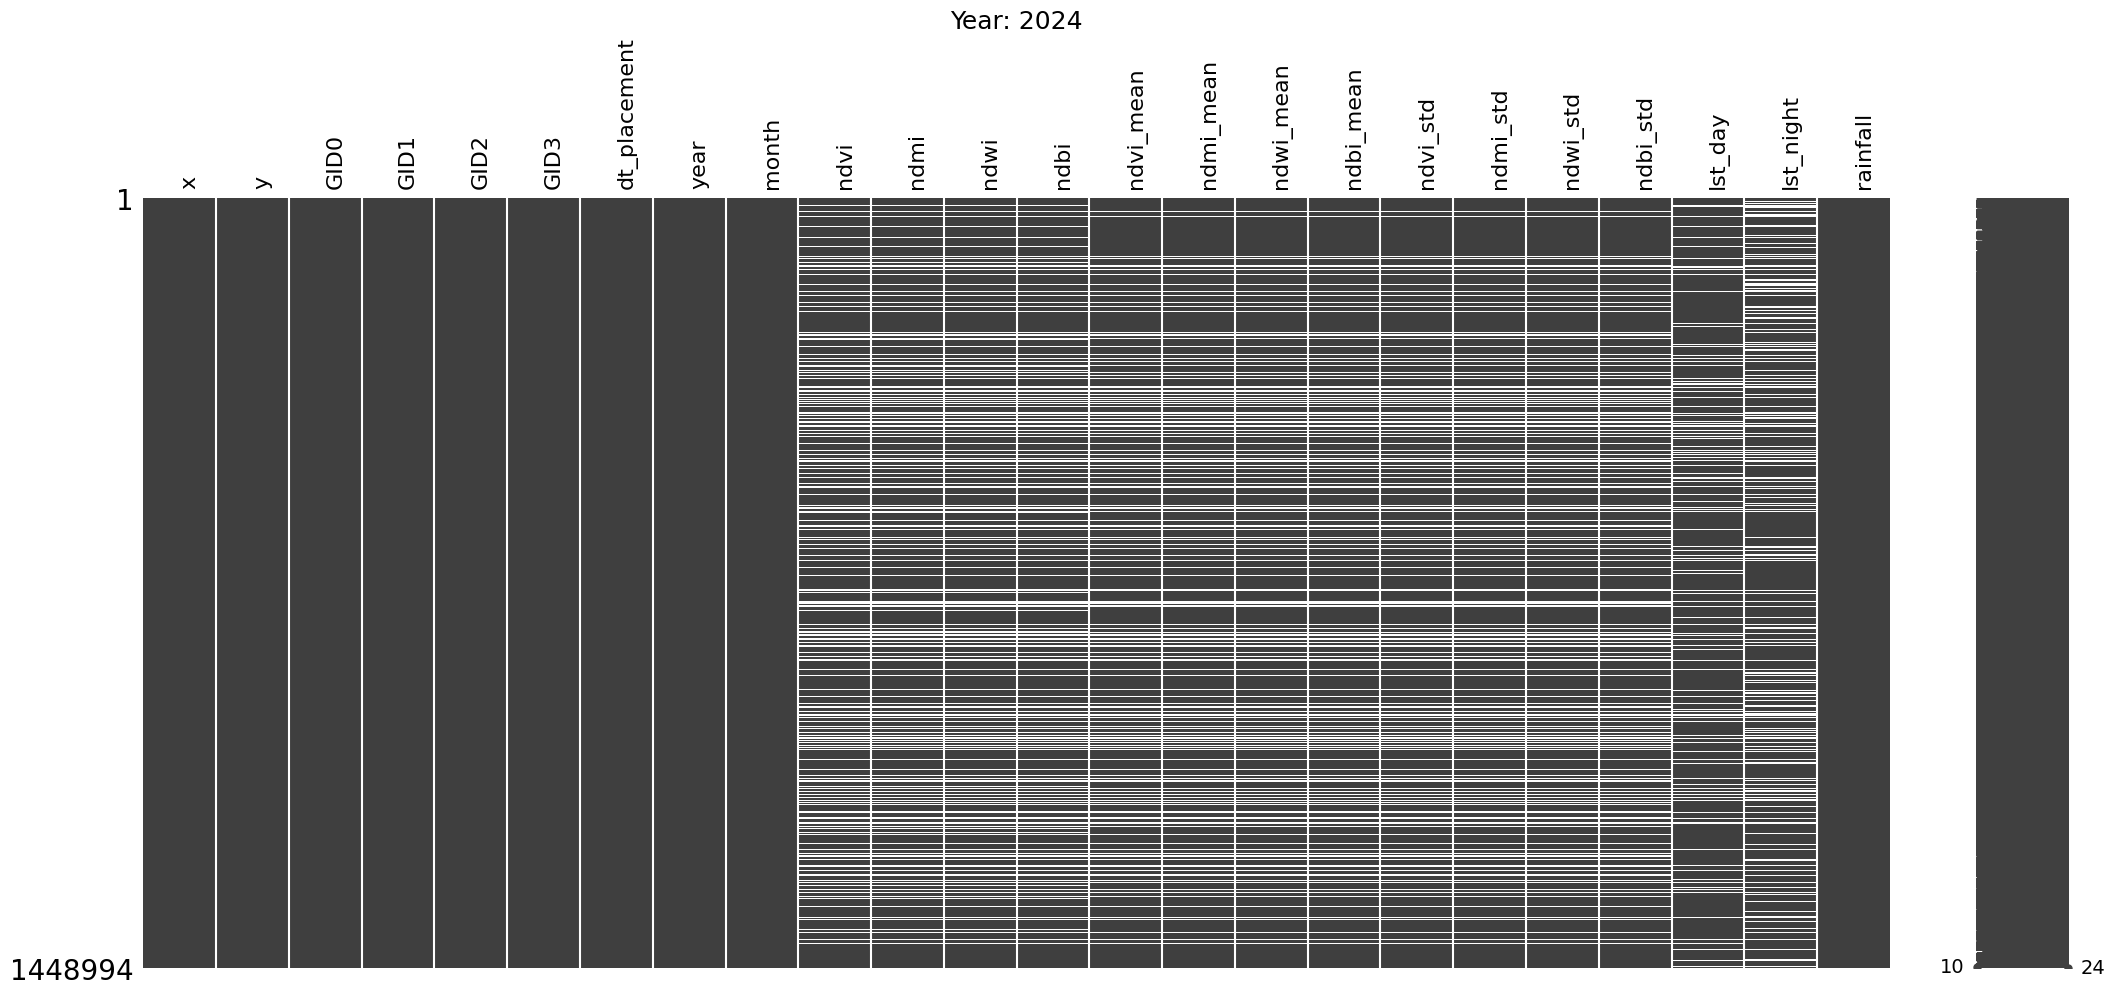

In [9]:
msno.matrix(timeline_file, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {timeline_file.year.iloc[0]}", fontsize=18)

In [10]:
timeline_file['lst'] = (timeline_file['lst_day'] + timeline_file['lst_night']) / 2

In [11]:
timeline_file = encode_cyclical(timeline_file, 'month', 12)

In [12]:
timeline_file.head()

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos
0,12.29306,8.21972,nord,faro,poli,balkossa,2024-01-01,2024,1,0.234069,-0.153430,-0.298374,0.153430,0.254741,-0.141299,-0.300685,0.141299,0.024187,0.032594,0.012017,0.032594,15247.0,14544.0,0.0,14895.5,0.5,0.866
1,12.29306,8.21972,nord,faro,poli,balkossa,2024-01-02,2024,1,0.234069,-0.153430,-0.298374,0.153430,0.254741,-0.141299,-0.300685,0.141299,0.024187,0.032594,0.012017,0.032594,15410.0,14544.0,0.0,14977.0,0.5,0.866
2,12.29306,8.21972,nord,faro,poli,balkossa,2024-01-03,2024,1,0.234069,-0.153430,-0.298374,0.153430,0.254741,-0.141299,-0.300685,0.141299,0.024187,0.032594,0.012017,0.032594,15410.0,14575.0,0.0,14992.5,0.5,0.866
3,12.29306,8.21972,nord,faro,poli,balkossa,2024-01-04,2024,1,0.234069,-0.153430,-0.298374,0.153430,0.254741,-0.141299,-0.300685,0.141299,0.024187,0.032594,0.012017,0.032594,15417.0,14521.0,0.0,14969.0,0.5,0.866
4,12.29306,8.21972,nord,faro,poli,balkossa,2024-01-05,2024,1,0.364624,-0.014147,-0.393515,0.014147,0.319521,-0.053684,-0.406543,0.053684,0.035530,0.029277,0.015771,0.029277,15451.0,14521.0,0.0,14986.0,0.5,0.866


In [13]:
geomorphological = pd.read_csv(f'../../data/{REGION}/CM_{REGION}_Geomorphological.csv', encoding=enc)
geomorphological.columns = geomorphological.columns.str.lower()
geomorphological.head()

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,13.56021,9.29772,15102.128622,680.892978,2,151.604907,185.418439,180.092206,0.0,1.000000
1,13.59642,9.22586,6838.003488,1865.794331,1,201.794101,197.674022,183.049512,0.0,2.249840
2,13.59642,9.26179,9504.069954,2074.586084,1,136.247919,186.061883,180.318899,0.0,9.050964
3,13.59642,9.29772,12864.041385,781.399397,1,143.777456,188.894941,180.250312,0.0,2.000000
4,13.63262,9.18992,1899.383898,1344.931378,1,151.874866,187.347864,179.798661,0.0,1.000000


In [14]:
geomorphological['x_rounded'] = geomorphological['x'].round(4)
geomorphological['y_rounded'] = geomorphological['y'].round(4)

geomorphological.drop(columns=['x', 'y'], inplace=True)

timeline_file['x_rounded'] = timeline_file['x'].round(4)
timeline_file['y_rounded'] = timeline_file['y'].round(4)

timeline_file = pd.merge(timeline_file, geomorphological, on=['x_rounded', 'y_rounded'], how='left')

timeline_file.head()

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,x_rounded,y_rounded,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,12.29306,8.21972,nord,faro,poli,balkossa,2024-01-01,2024,1,0.234069,-0.153430,-0.298374,0.153430,0.254741,-0.141299,-0.300685,0.141299,0.024187,0.032594,0.012017,0.032594,15247.0,14544.0,0.0,14895.5,0.5,0.866,12.2931,8.2197,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735
1,12.29306,8.21972,nord,faro,poli,balkossa,2024-01-02,2024,1,0.234069,-0.153430,-0.298374,0.153430,0.254741,-0.141299,-0.300685,0.141299,0.024187,0.032594,0.012017,0.032594,15410.0,14544.0,0.0,14977.0,0.5,0.866,12.2931,8.2197,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735
2,12.29306,8.21972,nord,faro,poli,balkossa,2024-01-03,2024,1,0.234069,-0.153430,-0.298374,0.153430,0.254741,-0.141299,-0.300685,0.141299,0.024187,0.032594,0.012017,0.032594,15410.0,14575.0,0.0,14992.5,0.5,0.866,12.2931,8.2197,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735
3,12.29306,8.21972,nord,faro,poli,balkossa,2024-01-04,2024,1,0.234069,-0.153430,-0.298374,0.153430,0.254741,-0.141299,-0.300685,0.141299,0.024187,0.032594,0.012017,0.032594,15417.0,14521.0,0.0,14969.0,0.5,0.866,12.2931,8.2197,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735
4,12.29306,8.21972,nord,faro,poli,balkossa,2024-01-05,2024,1,0.364624,-0.014147,-0.393515,0.014147,0.319521,-0.053684,-0.406543,0.053684,0.035530,0.029277,0.015771,0.029277,15451.0,14521.0,0.0,14986.0,0.5,0.866,12.2931,8.2197,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735


Text(0.5, 1.0, 'Year: 2024')

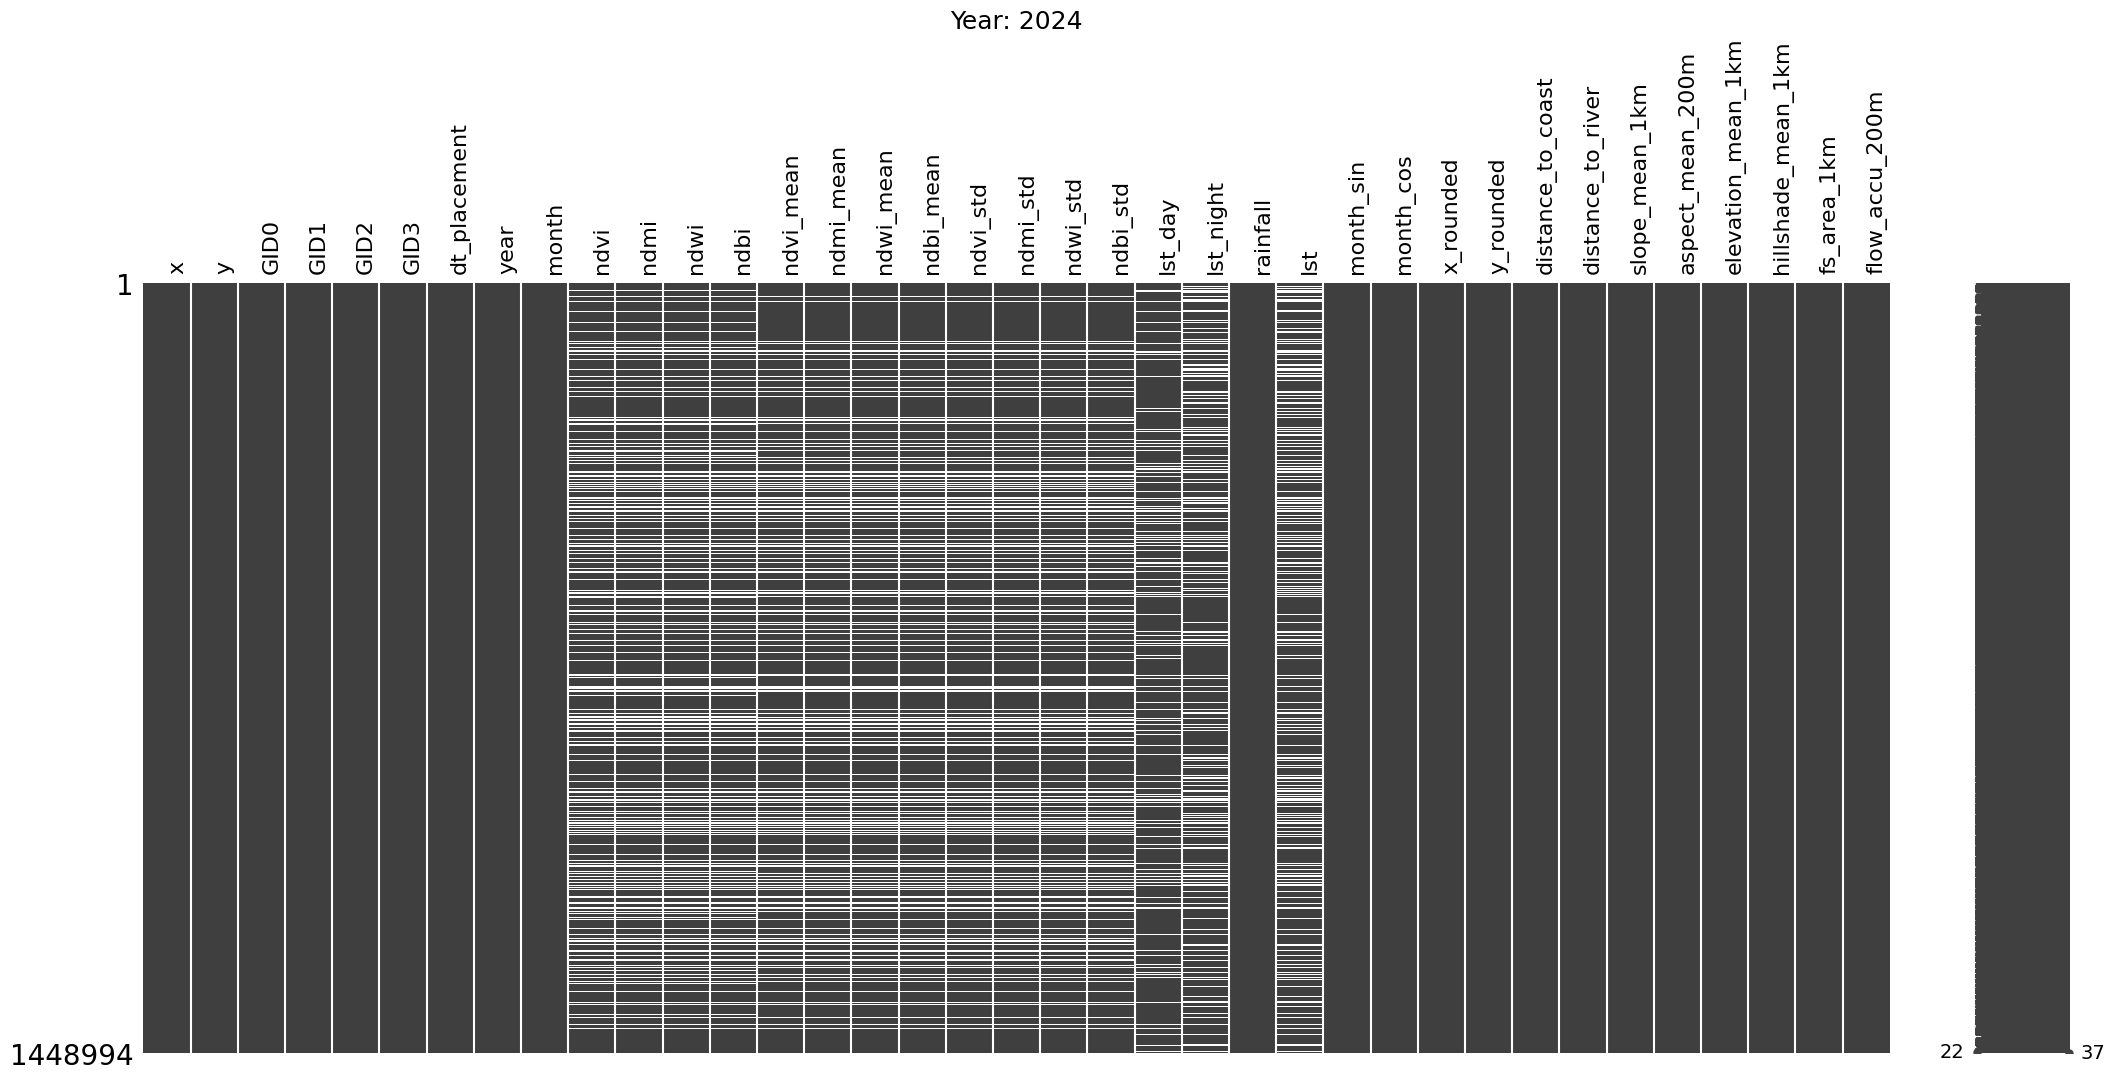

In [15]:
msno.matrix(timeline_file, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {timeline_file.year.iloc[0]}", fontsize=18)

In [16]:
# landcover data of previous year are merged

landcover = pd.read_csv(f'../../data/{REGION}/CM_{REGION}_Landcover_2001-2024_processed.csv')
landcover = landcover[landcover['year'] == YEAR - 1].copy()
landcover.head()

,x,y,year,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
87098,13.56021,9.29772,2023,31,99,36,98.0,30,99,12,12,1,6,7,2,0
87099,13.59642,9.22586,2023,31,99,36,99.0,30,99,12,12,3,5,8,2,0
87100,13.59642,9.26179,2023,31,98,36,97.0,30,98,12,12,1,6,7,2,0
87101,13.59642,9.29772,2023,31,98,36,97.0,30,98,12,12,1,6,7,2,0
87102,13.63262,9.18992,2023,31,99,36,99.0,30,99,12,12,1,6,7,2,0


In [17]:
landcover['x_rounded'] = landcover['x'].round(4)
landcover['y_rounded'] = landcover['y'].round(4)
landcover.rename(columns={'year': 'year_lc'}, inplace=True)
landcover.drop(columns=['x', 'y'], inplace=True)

timeline_file['year_lc'] = timeline_file['year'] - 1

In [18]:
timeline_file = pd.merge(timeline_file, landcover, on=['x_rounded', 'y_rounded', 'year_lc'], how='left')

timeline_file.head()

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,x_rounded,y_rounded,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,12.29306,8.21972,nord,faro,poli,balkossa,2024-01-01,2024,1,0.234069,-0.153430,-0.298374,0.153430,0.254741,-0.141299,-0.300685,0.141299,0.024187,0.032594,0.012017,0.032594,15247.0,14544.0,0.0,14895.5,0.5,0.866,12.2931,8.2197,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735,2023,31,99,36,96.0,30,99,12,12,1,6,7,2,0
1,12.29306,8.21972,nord,faro,poli,balkossa,2024-01-02,2024,1,0.234069,-0.153430,-0.298374,0.153430,0.254741,-0.141299,-0.300685,0.141299,0.024187,0.032594,0.012017,0.032594,15410.0,14544.0,0.0,14977.0,0.5,0.866,12.2931,8.2197,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735,2023,31,99,36,96.0,30,99,12,12,1,6,7,2,0
2,12.29306,8.21972,nord,faro,poli,balkossa,2024-01-03,2024,1,0.234069,-0.153430,-0.298374,0.153430,0.254741,-0.141299,-0.300685,0.141299,0.024187,0.032594,0.012017,0.032594,15410.0,14575.0,0.0,14992.5,0.5,0.866,12.2931,8.2197,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735,2023,31,99,36,96.0,30,99,12,12,1,6,7,2,0
3,12.29306,8.21972,nord,faro,poli,balkossa,2024-01-04,2024,1,0.234069,-0.153430,-0.298374,0.153430,0.254741,-0.141299,-0.300685,0.141299,0.024187,0.032594,0.012017,0.032594,15417.0,14521.0,0.0,14969.0,0.5,0.866,12.2931,8.2197,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735,2023,31,99,36,96.0,30,99,12,12,1,6,7,2,0
4,12.29306,8.21972,nord,faro,poli,balkossa,2024-01-05,2024,1,0.364624,-0.014147,-0.393515,0.014147,0.319521,-0.053684,-0.406543,0.053684,0.035530,0.029277,0.015771,0.029277,15451.0,14521.0,0.0,14986.0,0.5,0.866,12.2931,8.2197,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735,2023,31,99,36,96.0,30,99,12,12,1,6,7,2,0


In [19]:
timeline_file.loc[timeline_file['lc_prop1_assessment'] < 80, 'lc_prop1'] = np.nan
timeline_file.loc[timeline_file['lc_prop2_assessment'] < 80, 'lc_prop2'] = np.nan
timeline_file.loc[timeline_file['lc_prop3_assessment'] < 80, 'lc_prop3'] = np.nan

In [20]:
timeline_file.drop(columns=['x_rounded', 'y_rounded', 'lc_prop1_assessment', 'lc_prop2_assessment', 'lc_prop3_assessment', 'lw', 'qc'], inplace=True)

Text(0.5, 1.0, 'Year: 2024')

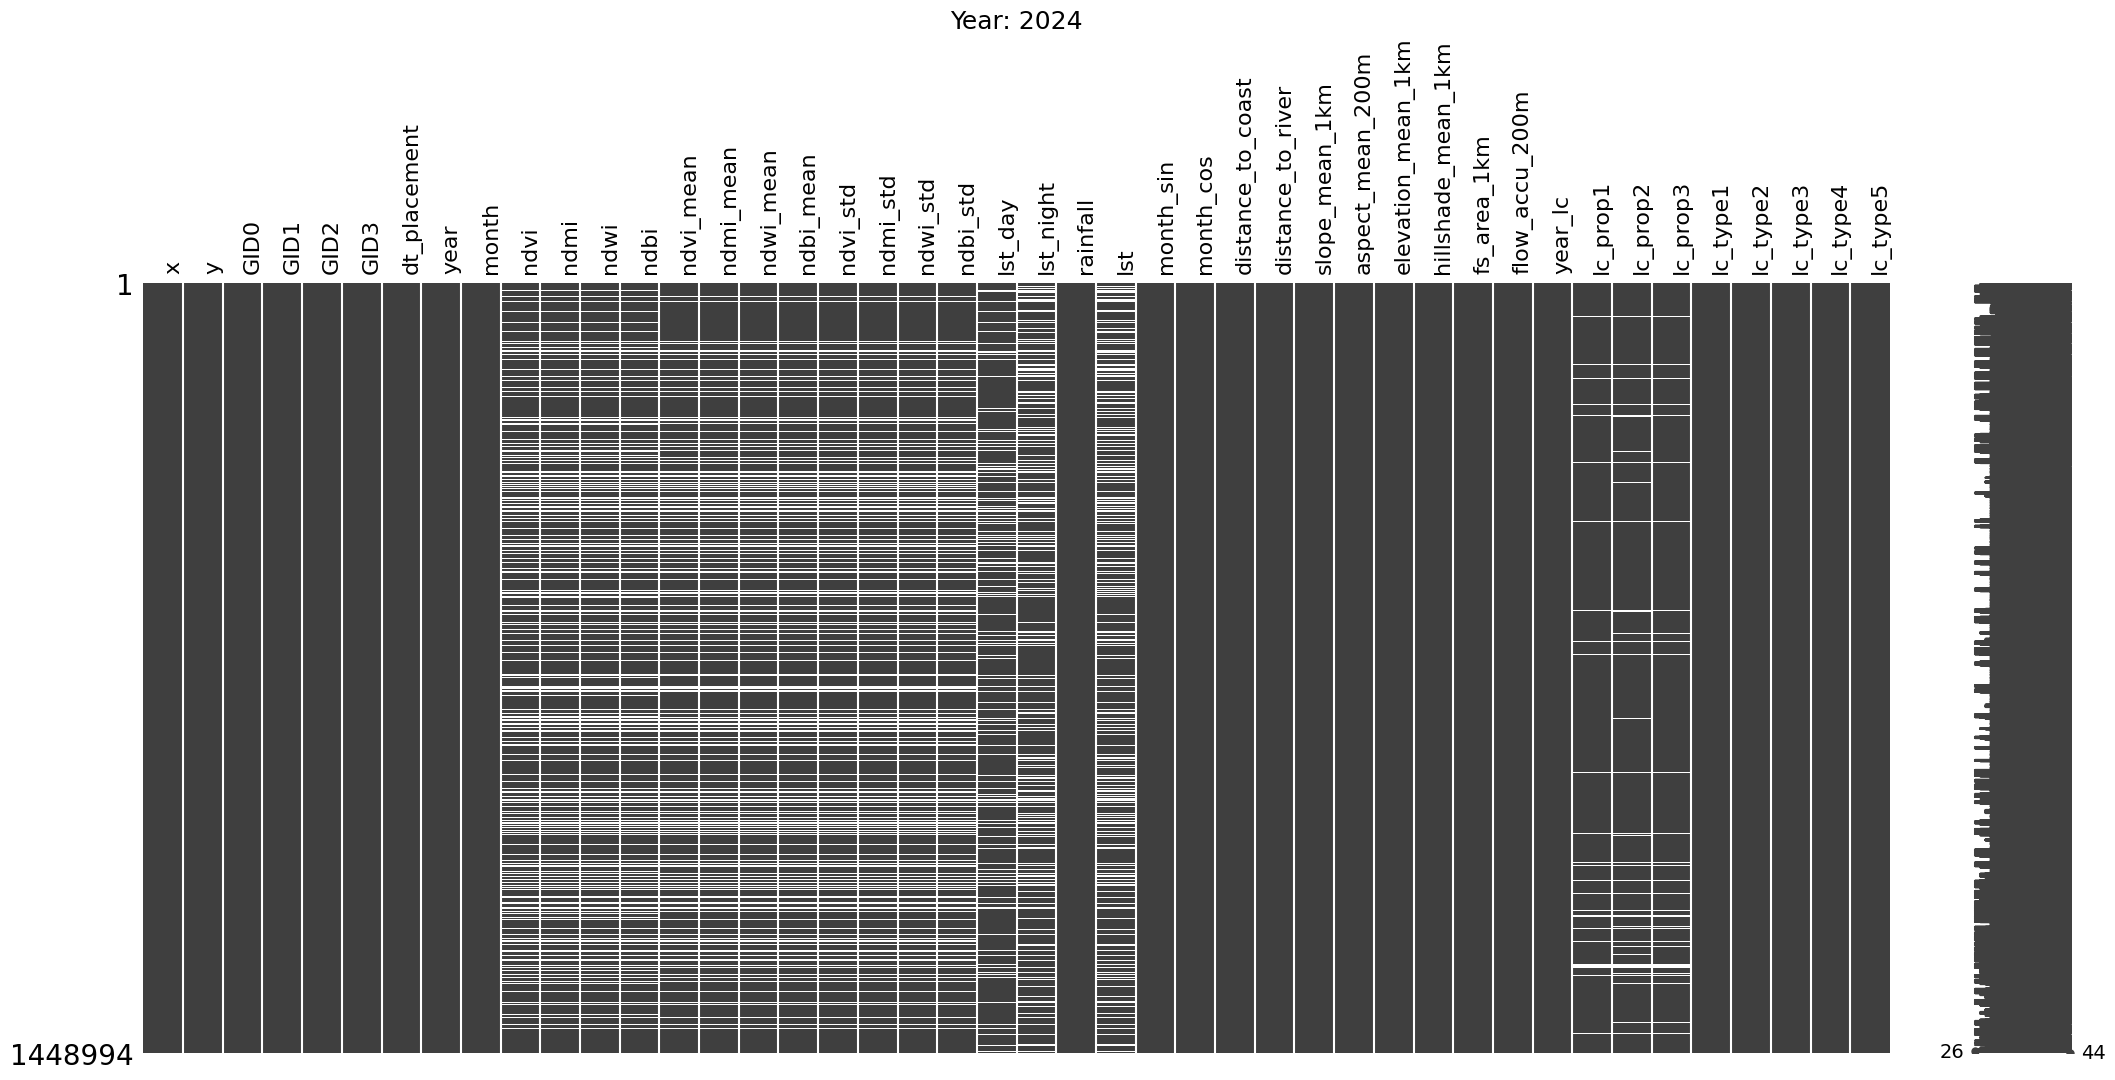

In [21]:
msno.matrix(timeline_file, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {timeline_file.year.iloc[0]}", fontsize=18)

In [22]:
timeline_file

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5
0,12.29306,8.21972,nord,faro,poli,balkossa,2024-01-01,2024,1,0.234069,-0.153430,-0.298374,0.153430,0.254741,-0.141299,-0.300685,0.141299,0.024187,0.032594,0.012017,0.032594,15247.0,14544.0,0.0,14895.5,0.5,0.866,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735,2023,31.0,36.0,30.0,12,12,1,6,7
1,12.29306,8.21972,nord,faro,poli,balkossa,2024-01-02,2024,1,0.234069,-0.153430,-0.298374,0.153430,0.254741,-0.141299,-0.300685,0.141299,0.024187,0.032594,0.012017,0.032594,15410.0,14544.0,0.0,14977.0,0.5,0.866,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735,2023,31.0,36.0,30.0,12,12,1,6,7
2,12.29306,8.21972,nord,faro,poli,balkossa,2024-01-03,2024,1,0.234069,-0.153430,-0.298374,0.153430,0.254741,-0.141299,-0.300685,0.141299,0.024187,0.032594,0.012017,0.032594,15410.0,14575.0,0.0,14992.5,0.5,0.866,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735,2023,31.0,36.0,30.0,12,12,1,6,7
3,12.29306,8.21972,nord,faro,poli,balkossa,2024-01-04,2024,1,0.234069,-0.153430,-0.298374,0.153430,0.254741,-0.141299,-0.300685,0.141299,0.024187,0.032594,0.012017,0.032594,15417.0,14521.0,0.0,14969.0,0.5,0.866,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735,2023,31.0,36.0,30.0,12,12,1,6,7
4,12.29306,8.21972,nord,faro,poli,balkossa,2024-01-05,2024,1,0.364624,-0.014147,-0.393515,0.014147,0.319521,-0.053684,-0.406543,0.053684,0.035530,0.029277,0.015771,0.029277,15451.0,14521.0,0.0,14986.0,0.5,0.866,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735,2023,31.0,36.0,30.0,12,12,1,6,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1448989,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2024-12-27,2024,12,0.254978,-0.129234,-0.289343,0.129234,0.295193,-0.097900,-0.305340,0.097900,0.086505,0.056897,0.051174,0.056897,15085.0,14441.0,0.0,14763.0,-0.0,1.000,75745.37949,68.862894,3,177.353198,461.652670,179.568663,0.0,3163.658249,2023,22.0,20.0,20.0,9,9,4,4,4
1448990,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2024-12-28,2024,12,0.254978,-0.129234,-0.289343,0.129234,0.295193,-0.097900,-0.305340,0.097900,0.086505,0.056897,0.051174,0.056897,15085.0,14476.0,0.0,14780.5,-0.0,1.000,75745.37949,68.862894,3,177.353198,461.652670,179.568663,0.0,3163.658249,2023,22.0,20.0,20.0,9,9,4,4,4
1448991,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2024-12-29,2024,12,0.254978,-0.129234,-0.289343,0.129234,0.295193,-0.097900,-0.305340,0.097900,0.086505,0.056897,0.051174,0.056897,15052.0,14453.0,0.0,14752.5,-0.0,1.000,75745.37949,68.862894,3,177.353198,461.652670,179.568663,0.0,3163.658249,2023,22.0,20.0,20.0,9,9,4,4,4
1448992,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2024-12-30,2024,12,0.243278,-0.137847,-0.282271,0.137847,0.280358,-0.107628,-0.296999,0.107628,0.080038,0.052339,0.048076,0.052339,15157.0,14453.0,0.0,14805.0,-0.0,1.000,75745.37949,68.862894,3,177.353198,461.652670,179.568663,0.0,3163.658249,2023,22.0,20.0,20.0,9,9,4,4,4


In [23]:
timeline_file.describe()

,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5
count,1.448994e+06,1.448994e+06,1448994.0,1.448994e+06,1.095370e+06,1.095332e+06,1.095370e+06,1.095332e+06,1.148670e+06,1.148644e+06,1.148675e+06,1.148526e+06,1.148670e+06,1.148644e+06,1.148675e+06,1.148526e+06,1.210388e+06,1.128187e+06,1.448994e+06,1.074221e+06,1.448994e+06,1.448994e+06,1.448994e+06,1.448994e+06,1.448994e+06,1.448994e+06,1.448994e+06,1.448994e+06,1.448994e+06,1.448994e+06,1448994.0,1.396656e+06,1.381650e+06,1.390800e+06,1.448994e+06,1.448994e+06,1.448994e+06,1.448994e+06,1.448994e+06
mean,1.394363e+01,8.485321e+00,2024.0,6.513661e+00,3.581476e-01,1.202819e-02,-3.306250e-01,-1.202819e-02,3.585945e-01,1.781550e-02,-3.293775e-01,-1.780306e-02,2.773458e-02,2.652124e-02,2.291406e-02,2.652170e-02,1.526080e+04,1.472632e+04,6.830673e+00,1.499492e+04,-3.000000e-03,-1.000000e-03,7.263910e+04,1.430515e+03,4.528669e+00,1.618835e+02,4.953245e+02,1.799451e+02,2.239887e-02,7.795053e+02,2023.0,2.706656e+01,2.814834e+01,2.571342e+01,1.041930e+01,1.021293e+01,3.027280e+00,4.592069e+00,5.695378e+00
std,7.548784e-01,7.046535e-01,0.0,3.451235e+00,1.864587e-01,1.697383e-01,1.259408e-01,1.697383e-01,1.813314e-01,1.670733e-01,1.213742e-01,1.670569e-01,2.547026e-02,2.137359e-02,2.538539e-02,2.137368e-02,2.796416e+02,1.764060e+02,1.542978e+01,1.889650e+02,7.061237e-01,7.080612e-01,4.473122e+04,9.846611e+02,5.704843e+00,4.624303e+01,2.652512e+02,5.401438e+00,2.377980e-01,9.470593e+03,0.0,5.021734e+00,7.663124e+00,5.464214e+00,1.704190e+00,1.772022e+00,1.233024e+00,1.142333e+00,2.074797e+00
min,1.229306e+01,7.069850e+00,2024.0,1.000000e+00,-5.227538e-01,-5.040811e-01,-1.034871e+00,-8.434343e-01,-5.147782e-01,-3.051389e-01,-1.034871e+00,-8.516978e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.364500e+04,1.389900e+04,0.000000e+00,1.432350e+04,-1.000000e+00,-1.000000e+00,1.660909e+01,5.129964e-04,0.000000e+00,0.000000e+00,1.691704e+02,1.196138e+02,0.000000e+00,1.000000e+00,2023.0,3.000000e+00,3.000000e+00,3.000000e+00,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.334299e+01,7.968190e+00,2024.0,4.000000e+00,2.027175e-01,-1.296534e-01,-4.194541e-01,-1.531935e-01,2.048286e-01,-1.240755e-01,-4.177519e-01,-1.620172e-01,1.313826e-02,1.355995e-02,1.050753e-02,1.355995e-02,1.505700e+04,1.459600e+04,0.000000e+00,1.486100e+04,-8.660000e-01,-8.660000e-01,3.328515e+04,6.102712e+02,2.000000e+00,1.315493e+02,3.082905e+02,1.785421e+02,0.000000e+00,1.224904e+00,2023.0,2.200000e+01,2.000000e+01,2.000000e+01,9.000000e+00,9.000000e+00,3.000000e+00,4.000000e+00,4.000000e+00
50%,1.392226e+01,8.399390e+00,2024.0,7.000000e+00,3.346056e-01,-2.762991e-02,-3.387675e-01,2.762991e-02,3.398973e-01,-1.801962e-02,-3.378214e-01,1.804864e-02,2.170876e-02,2.170435e-02,1.682533e-02,2.170445e-02,1.520900e+04,1.473200e+04,6.000000e-02,1.496650e+04,-0.000000e+00,-0.000000e+00,7.134045e+04,1.266644e+03,3.000000e+00,1.616719e+02,4.114362e+02,1.800481e+02,0.000000e+00,2.444942e+00,2023.0,3.100000e+01,3.000000e+01,3.000000e+01,1.000000e+01,1.000000e+01,3.000000e+00,5.000000e+00,6.000000e+00
75%,1.453774e+01,8.974320e+00,2024.0,1.000000e+01,5.262136e-01,1.531935e-01,-2.546365e-01,1.296534e-01,5.231304e-01,1.620189e-01,-2.528550e-01,1.240755e-01,3.461445e-02,3.364002e-02,2.697739e-02,3.364059e-02,1.546100e+04,1.484400e+04,5.630000e+00,1.510800e+04,5.000000e-01,8.660000e-01,1.055138e+05,2.112235e+03,5.000000e+00,1.920474e+02,6.036195e+02,1.815590e+02,0.000000e+00,8.774023e+00,2023.0,3.100000e+01,3.600000e+01,3.000000e+01,1.200000e+01,1.200000e+01,4.000000e+00,5.000000e+00,8.000000e+00
max,1.555146e+01,1.023199e+01,2024.0,1.200000e+01,7.881458e-01,8.434343e-01,8.792041e-01,5.04081

In [24]:
gid_unit_counts = []

for gid_unit in timeline_file.GID3.sort_values().unique().tolist():
    count = (timeline_file['GID3'] == gid_unit).sum()
    gid_unit_counts.append({'GID3': gid_unit,
                            'count': count})

gid_unit_counts_df = pd.DataFrame(gid_unit_counts)

In [25]:
gid_unit_counts_df.head()

,GID3,count
0,adoumri,1830
1,alpha,24888
2,babla,2928
3,babouri,1464
4,badadji,1098


In [26]:
gid_unit_counts_df.describe()

,count
count,144.000000
mean,10062.458333
std,16732.581228
min,366.000000
25%,1830.000000
50%,4026.000000
75%,10339.500000
max,127734.000000


In [27]:
fig = px.bar(gid_unit_counts_df, x='GID3', y='count', title='Count per Region')
fig.update_layout(xaxis_title='Region (GID3)', yaxis_title='Count')
fig.show()

In [28]:
group_cols = ['dt_placement', 'GID0', 'GID1', 'GID2', 'GID3']
mode_cols = ['lc_prop1','lc_prop2','lc_prop3','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5']
geo_cols = ['distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m']

grouped_by_gid3 = timeline_file.groupby(group_cols, as_index = False)

grouped_by_gid3_mean = grouped_by_gid3.mean()
grouped_by_gid3_std = grouped_by_gid3.std()

grouped_by_gid3_most_common = timeline_file[group_cols].drop_duplicates()

for col in mode_cols:
    mode_series = (timeline_file.groupby(group_cols)[col].value_counts().groupby(level=group_cols).idxmax().apply(lambda x: x[-1]).reset_index(name=col))
    grouped_by_gid3_most_common = grouped_by_gid3_most_common.merge(mode_series, on=group_cols, how='left')


In [29]:
grouped_by_gid3_mean.drop(columns = mode_cols, inplace=True)
grouped_by_gid3_std = grouped_by_gid3_std[group_cols + geo_cols].copy()
grouped_by_gid3_std.columns = group_cols + [f"{col}_std" for col in geo_cols]

In [30]:
grouped_by_gid3 = grouped_by_gid3_mean.merge(grouped_by_gid3_std, on=group_cols, how='left')
grouped_by_gid3 = grouped_by_gid3.merge(grouped_by_gid3_most_common, on=group_cols, how='left')

In [31]:
print(f'Shape of the grouped_by_gid3 file: {grouped_by_gid3.shape}')

Shape of the grouped_by_gid3 file: (53070, 52)


Text(0.5, 1.0, 'Year: 2024.0')

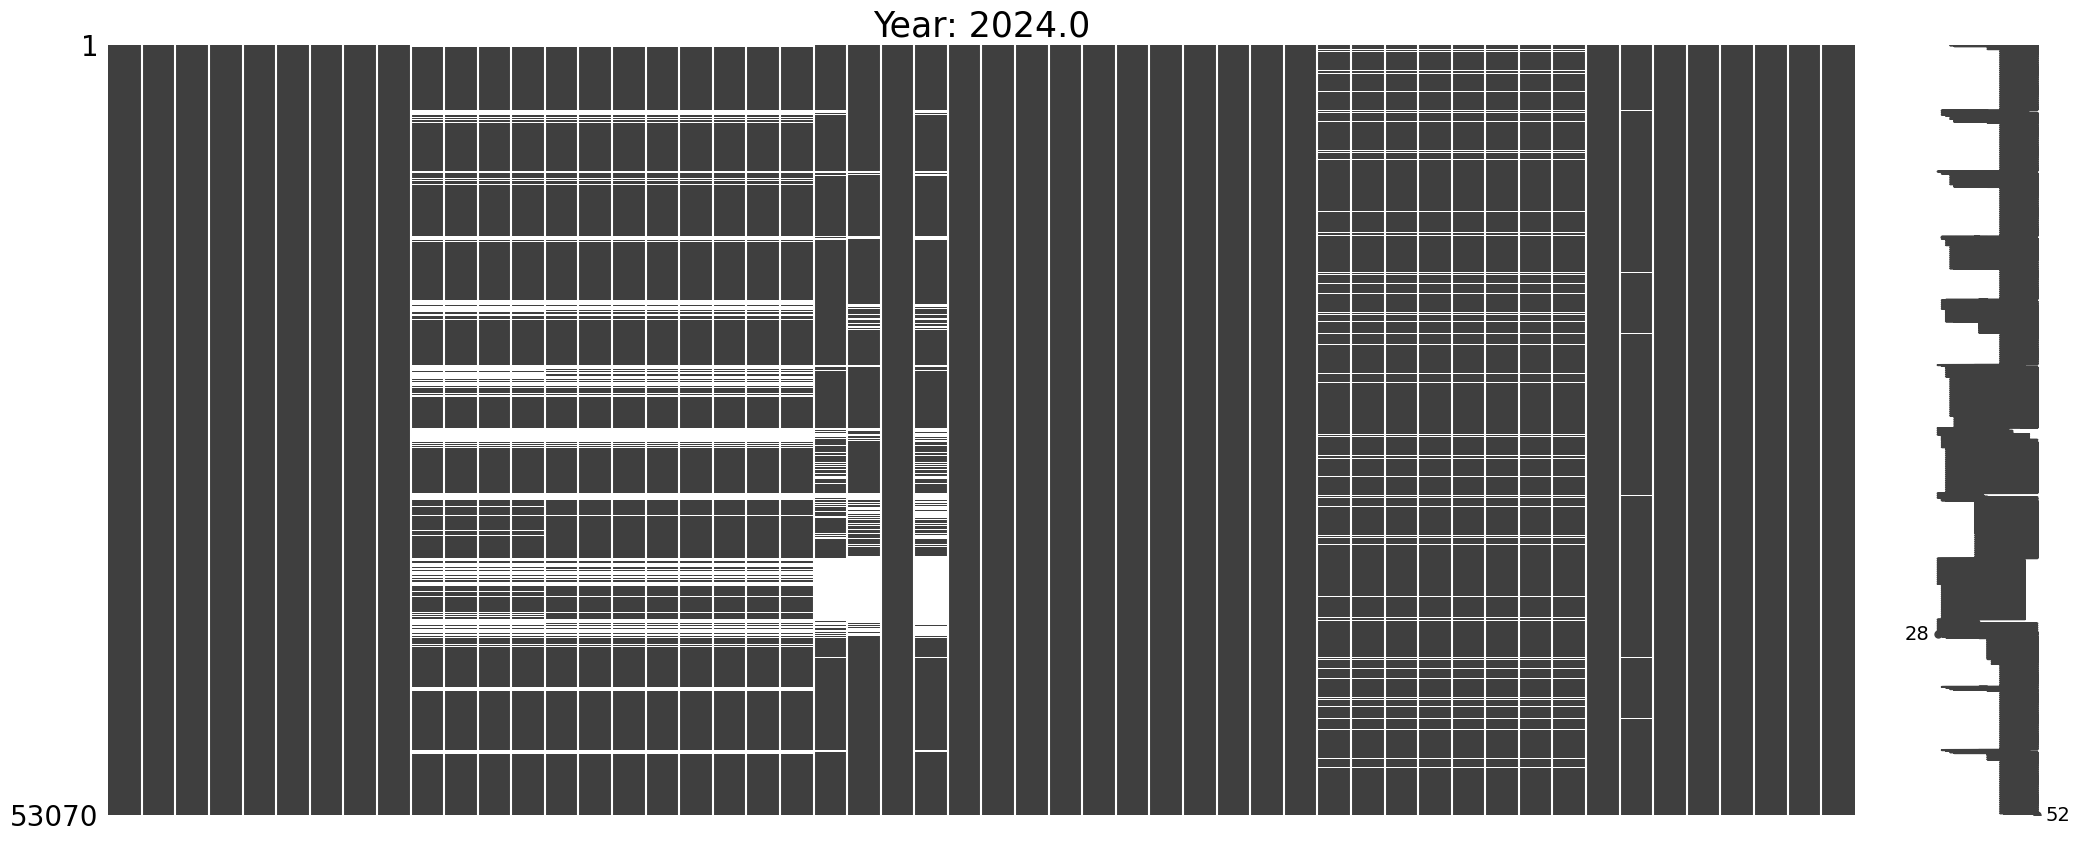

In [32]:
msno.matrix(grouped_by_gid3, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {grouped_by_gid3.year.iloc[0]}", fontsize=25)

In [33]:
gid_mean_unit_counts = []

for gid_unit in grouped_by_gid3.GID3.sort_values().unique().tolist():
    count = (grouped_by_gid3['GID3'] == gid_unit).sum()
    gid_mean_unit_counts.append({'GID3': gid_unit,
                            'count': count})

gid_mean_unit_counts_df = pd.DataFrame(gid_mean_unit_counts)

In [34]:
fig = px.bar(gid_mean_unit_counts_df, x='GID3', y='count', title='Count per Region')
fig.update_layout(xaxis_title='Region (GID3)', yaxis_title='Count')
fig.show()

In [35]:
grouped_by_gid3 = convert_temperature(grouped_by_gid3)

In [36]:
grouped_by_gid3.head()

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5
0,2024-01-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2024.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.850000,18.730000,0.0,27.790000,0.5,0.866,11525.501547,1189.566737,3.200000,176.556138,234.750015,181.293075,0.0,4.122890,2023.0,2812.420746,750.981640,1.788854,48.896611,24.034117,1.205482,0.0,5.969408,31.0,36.0,30.0,12,12,3,5,8
1,2024-01-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2024.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.788462,19.585385,0.0,27.686923,0.5,0.866,27643.505181,1357.065997,2.871795,173.781355,293.252756,180.811286,0.0,92.996499,2023.0,6064.190727,931.673366,1.641236,38.303046,43.861207,1.301525,0.0,459.006647,31.0,36.0,30.0,12,12,3,5,8
2,2024-01-01,nord,benoue,bibemi,bide,13.972945,9.422292,2024.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.330000,19.215333,0.0,27.272667,0.5,0.866,22660.822965,1318.020573,2.600000,168.650613,304.317929,180.301336,0.0,93.489080,2023.0,5555.845612,719.271733,1.242118,31.219410,20.072188,1.639950,0.0,330.447001,31.0,36.0,30.0,12,12,3,5,8
3,2024-01-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2024.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.713636,18.980909,0.0,26.847273,0.5,0.866,6789.434645,1430.318925,2.181818,167.127816,200.161964,180.523037,0.0,5.106007,2023.0,4263.616083,736.589253,1.167748,24.830296,14.391049,1.040369,0.0,7.221327,31.0,36.0,30.0,12,12,3,5,8
4,2024-01-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2024.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.776667,20.723333,0.0,27.750000,0.5,0.866,5443.506799,2018.690644,9.333333,194.838800,332.209587,175.000090,0.0,6.187549,2023.0,4805.139710,451.444712,9.712535,47.638218,77.268242,7.151423,0.0,7.464223,31.0,36.0,30.0,12,12,3,5,8


In [37]:
grouped_by_gid3['year'] = grouped_by_gid3['year'].astype(int)
grouped_by_gid3['year_lc'] = grouped_by_gid3['year_lc'].astype(int)
grouped_by_gid3['month'] = grouped_by_gid3['month'].astype(int)

In [38]:
grouped_by_gid3.head()

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5
0,2024-01-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.850000,18.730000,0.0,27.790000,0.5,0.866,11525.501547,1189.566737,3.200000,176.556138,234.750015,181.293075,0.0,4.122890,2023,2812.420746,750.981640,1.788854,48.896611,24.034117,1.205482,0.0,5.969408,31.0,36.0,30.0,12,12,3,5,8
1,2024-01-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.788462,19.585385,0.0,27.686923,0.5,0.866,27643.505181,1357.065997,2.871795,173.781355,293.252756,180.811286,0.0,92.996499,2023,6064.190727,931.673366,1.641236,38.303046,43.861207,1.301525,0.0,459.006647,31.0,36.0,30.0,12,12,3,5,8
2,2024-01-01,nord,benoue,bibemi,bide,13.972945,9.422292,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.330000,19.215333,0.0,27.272667,0.5,0.866,22660.822965,1318.020573,2.600000,168.650613,304.317929,180.301336,0.0,93.489080,2023,5555.845612,719.271733,1.242118,31.219410,20.072188,1.639950,0.0,330.447001,31.0,36.0,30.0,12,12,3,5,8
3,2024-01-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.713636,18.980909,0.0,26.847273,0.5,0.866,6789.434645,1430.318925,2.181818,167.127816,200.161964,180.523037,0.0,5.106007,2023,4263.616083,736.589253,1.167748,24.830296,14.391049,1.040369,0.0,7.221327,31.0,36.0,30.0,12,12,3,5,8
4,2024-01-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.776667,20.723333,0.0,27.750000,0.5,0.866,5443.506799,2018.690644,9.333333,194.838800,332.209587,175.000090,0.0,6.187549,2023,4805.139710,451.444712,9.712535,47.638218,77.268242,7.151423,0.0,7.464223,31.0,36.0,30.0,12,12,3,5,8


Text(0.5, 1.0, 'Year: 2024')

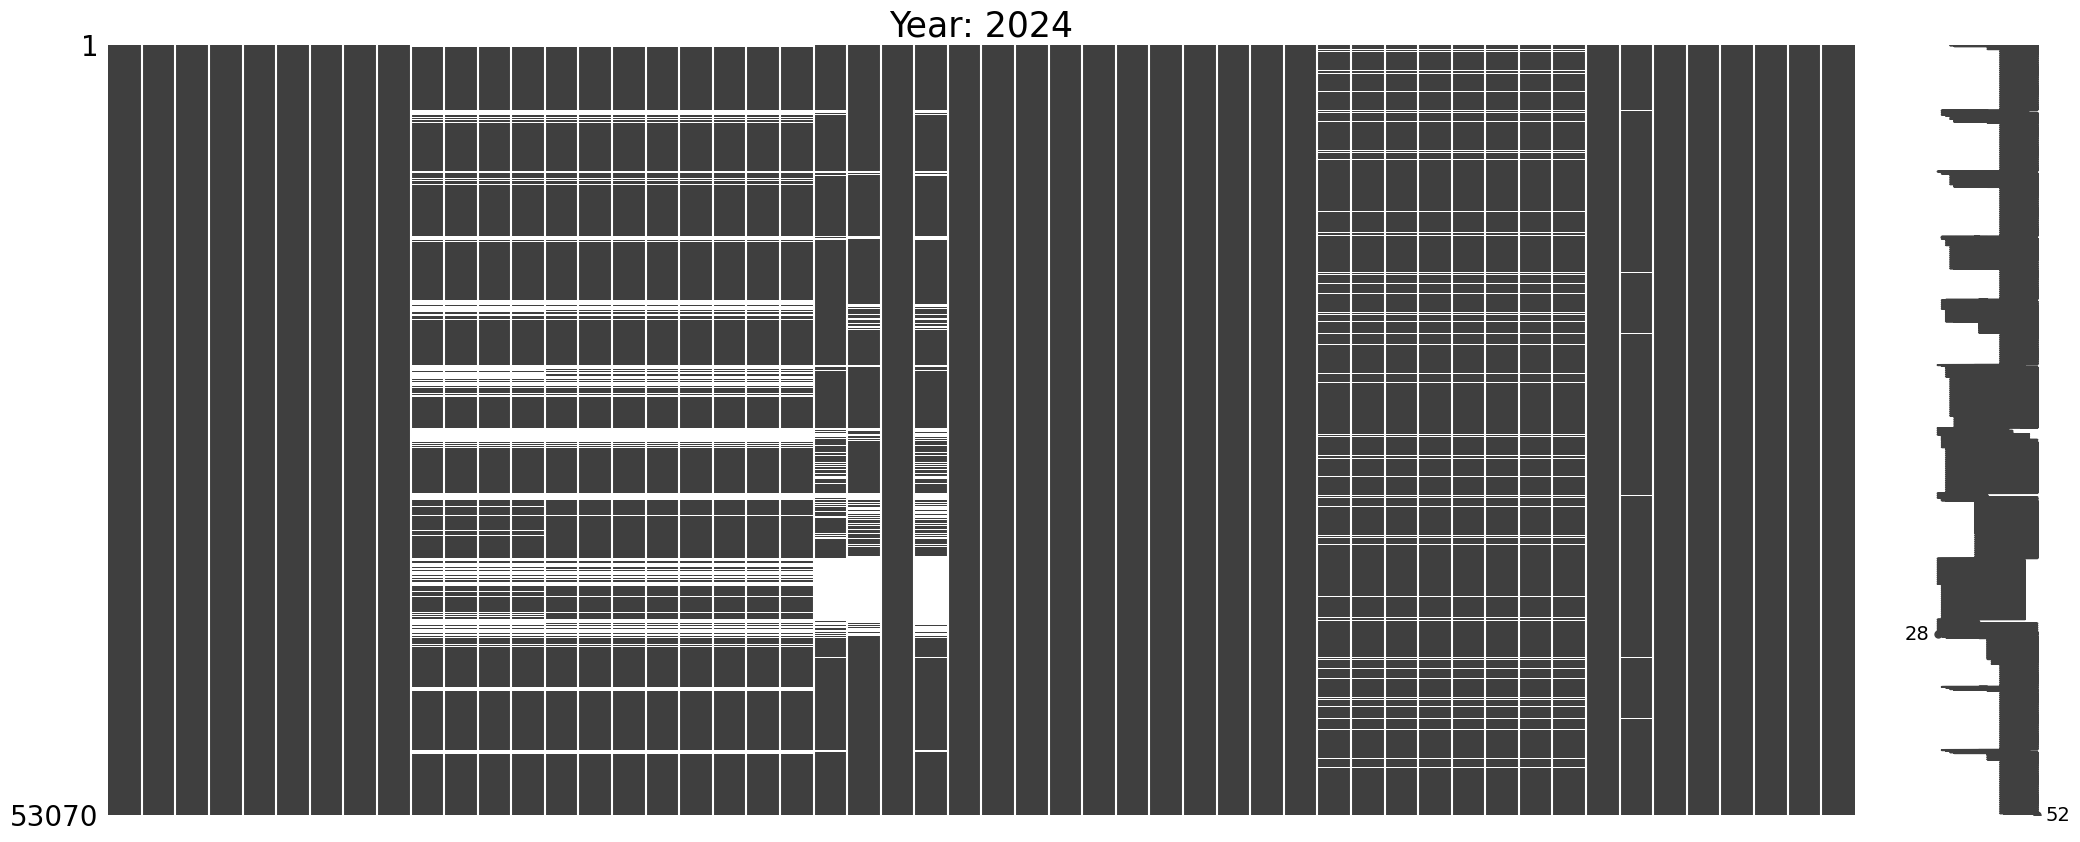

In [39]:
msno.matrix(grouped_by_gid3, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {grouped_by_gid3.year.iloc[0]}", fontsize=25)

In [40]:
grouped_by_gid3.describe()

,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5
count,53070.000000,53070.000000,53070.0,53070.000000,43567.000000,43565.000000,43567.000000,43565.000000,44612.000000,44612.000000,44612.000000,44610.000000,44612.000000,44612.000000,44612.000000,44610.000000,44724.000000,44374.000000,53070.000000,42249.000000,53070.00000,53070.000000,53070.000000,53070.000000,53070.000000,53070.000000,53070.000000,53070.000000,53070.000000,53070.000000,53070.0,49776.000000,49776.000000,49776.000000,49776.000000,49776.000000,49776.000000,49776.000000,49776.000000,53070.000000,52704.000000,53070.000000,53070.000000,53070.000000,53070.000000,53070.000000,53070.000000
mean,13.774721,9.158610,2024.0,6.513661,0.308914,-0.028708,-0.322899,0.028708,0.306804,-0.026199,-0.320226,0.026255,0.028672,0.027224,0.023510,0.027227,33.876222,22.465700,5.704135,28.203356,-0.00300,-0.001000,41654.661825,1428.029921,3.729529,159.308885,376.388821,179.630904,0.024979,1094.054790,2023.0,5837.697758,934.910824,3.658201,37.898242,69.615188,3.553276,0.052659,3787.105701,30.013793,32.833333,28.896552,11.510345,11.510345,3.048276,5.013793,7.365517
std,0.567528,0.678537,0.0,3.451266,0.161264,0.145469,0.100313,0.145469,0.155629,0.143240,0.094853,0.143144,0.020495,0.018760,0.018668,0.018759,5.000764,3.144659,13.267994,3.400379,0.70613,0.708068,32583.261508,459.633646,2.224654,18.925191,167.384003,1.731779,0.121316,3664.311871,0.0,4226.712234,284.768507,2.989741,15.141190,72.235381,4.021164,0.227847,10988.842587,2.823539,6.687531,3.133220,1.083537,1.083537,1.239205,0.621308,1.378737
min,12.383569,7.276898,2024.0,1.000000,-0.470417,-0.272467,-0.549266,-0.750323,-0.403845,-0.266359,-0.535783,-0.750323,0.000000,0.000000,0.000000,0.000000,4.370000,11.365000,0.000000,18.396038,-1.00000,-1.000000,2107.273950,142.990406,0.666667,84.672313,179.122926,172.180250,0.000000,1.129111,2023.0,109.196799,189.666077,0.500000,1.854461,2.333805,0.041012,0.000000,0.134126,22.000000,9.000000,20.000000,9.000000,9.000000,1.000000,4.000000,4.000000
25%,13.440741,8.789951,2024.0,4.000000,0.176170,-0.147584,-0.398138,-0.081963,0.175802,-0.143975,-0.394161,-0.088980,0.014856,0.015266,0.013154,0.015266,29.983182,20.263333,0.000000,25.846000,-0.86600,-0.866000,18537.260762,1218.217279,2.220588,150.782168,248.536063,179.145577,0.000000,7.056847,2023.0,3334.200586,783.651628,1.477368,27.804608,21.719200,1.263409,0.000000,14.011861,31.000000,36.000000,30.000000,12.000000,12.000000,3.000000,5.000000,8.000000
50%,13.707817,9.286943,2024.0,7.000000,0.266379,-0.072961,-0.326231,0.072961,0.266375,-0.069115,-0.323037,0.069147,0.024718,0.023934,0.018798,0.023934,33.492762,22.582614,0.090000,27.522500,0.00000,0.000000,29895.396877,1450.222681,3.055556,162.545910,331.761974,180.046801,0.000000,42.730502,2023.0,4500.068289,975.250678,2.444583,39.063645,40.891866,2.122457,0.000000,135.277674,31.000000,36.000000,30.000000,12.000000,12.000000,3.000000,5.000000,8.000000
75%,13.994668,9.696256,2024.0,10.000000,0.448145,0.081963,-0.256541,0.147584,0.442757,0.088980,-0.253795,0.143986,0.036520,0.034234,0.028182,0.034234,37.671333,24.410000,3.630000,30.567500,0.50000,0.866000,57865.678799,1616.602077,4.625000,169.274173,448.096953,180.577534,0.000000,379.689941,2023.0,6828.521411,1082.475494,5.279347,47.689146,90.134013,4.253803,0.000000,1666.470062,31.000000,36.000000,30.000000,12.000000,12.000000,3.000000,5.000000,8.000000
max,15.461737,10.196057,2024.0,12.000000,0.705702,0.750323,0.785241,0.272467,0.703254,0.750323,0.635115,0.266359,0.24498

In [41]:
# Group by the needed dimensions
grouped_mask = grouped_by_gid3.groupby(['GID2', 'GID3', 'year', 'month'])

# Compute the min and max temperature across lst_day and lst_night
monthly_lst_min = grouped_mask[['lst_day', 'lst_night']].min().min(axis=1)
monthly_lst_max = grouped_mask[['lst_day', 'lst_night']].max().max(axis=1)

# Compute total precipitation
monthly_rainfall_acc = grouped_mask['rainfall'].sum()

# Combine results into a single DataFrame
min_max_acc_weather_df = pd.DataFrame({
    'monthly_lst_min': monthly_lst_min,
    'monthly_lst_max': monthly_lst_max,
    'monthly_rainfall_acc': monthly_rainfall_acc
}).reset_index()

In [42]:
min_max_acc_weather_df

,GID2,GID3,year,month,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc
0,bibemi,adoumri,2024,1,15.314000,40.866000,0.008000
1,bibemi,adoumri,2024,2,16.606000,44.526000,2.760000
2,bibemi,adoumri,2024,3,21.135000,45.958000,10.136000
3,bibemi,adoumri,2024,4,24.826000,44.698000,38.855999
4,bibemi,adoumri,2024,5,24.666000,43.746000,83.431998
...,...,...,...,...,...,...,...
1735,touboro,yanli,2024,8,21.051818,28.792581,741.426757
1736,touboro,yanli,2024,9,NaN,NaN,358.325798
1737,touboro,yanli,2024,10,19.950000,30.564839,350.386766
1738,touboro,yanli,2024,11,15.631935,32.993871,0.267097


In [43]:
dataset = pd.merge(grouped_by_gid3, min_max_acc_weather_df, on=['GID2', 'GID3', 'year', 'month'], how='left')

In [44]:
dataset.head()

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc
0,2024-01-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.850000,18.730000,0.0,27.790000,0.5,0.866,11525.501547,1189.566737,3.200000,176.556138,234.750015,181.293075,0.0,4.122890,2023,2812.420746,750.981640,1.788854,48.896611,24.034117,1.205482,0.0,5.969408,31.0,36.0,30.0,12,12,3,5,8,15.314000,40.866000,0.008000
1,2024-01-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.788462,19.585385,0.0,27.686923,0.5,0.866,27643.505181,1357.065997,2.871795,173.781355,293.252756,180.811286,0.0,92.996499,2023,6064.190727,931.673366,1.641236,38.303046,43.861207,1.301525,0.0,459.006647,31.0,36.0,30.0,12,12,3,5,8,16.478205,39.986923,0.695641
2,2024-01-01,nord,benoue,bibemi,bide,13.972945,9.422292,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.330000,19.215333,0.0,27.272667,0.5,0.866,22660.822965,1318.020573,2.600000,168.650613,304.317929,180.301336,0.0,93.489080,2023,5555.845612,719.271733,1.242118,31.219410,20.072188,1.639950,0.0,330.447001,31.0,36.0,30.0,12,12,3,5,8,16.536667,39.618000,1.175333
3,2024-01-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.713636,18.980909,0.0,26.847273,0.5,0.866,6789.434645,1430.318925,2.181818,167.127816,200.161964,180.523037,0.0,5.106007,2023,4263.616083,736.589253,1.167748,24.830296,14.391049,1.040369,0.0,7.221327,31.0,36.0,30.0,12,12,3,5,8,15.319091,38.633636,0.063636
4,2024-01-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.776667,20.723333,0.0,27.750000,0.5,0.866,5443.506799,2018.690644,9.333333,194.838800,332.209587,175.000090,0.0,6.187549,2023,4805.139710,451.444712,9.712535,47.638218,77.268242,7.151423,0.0,7.464223,31.0,36.0,30.0,12,12,3,5,8,17.536667,39.523333,0.323333


Text(0.5, 1.0, 'Year: 2024')

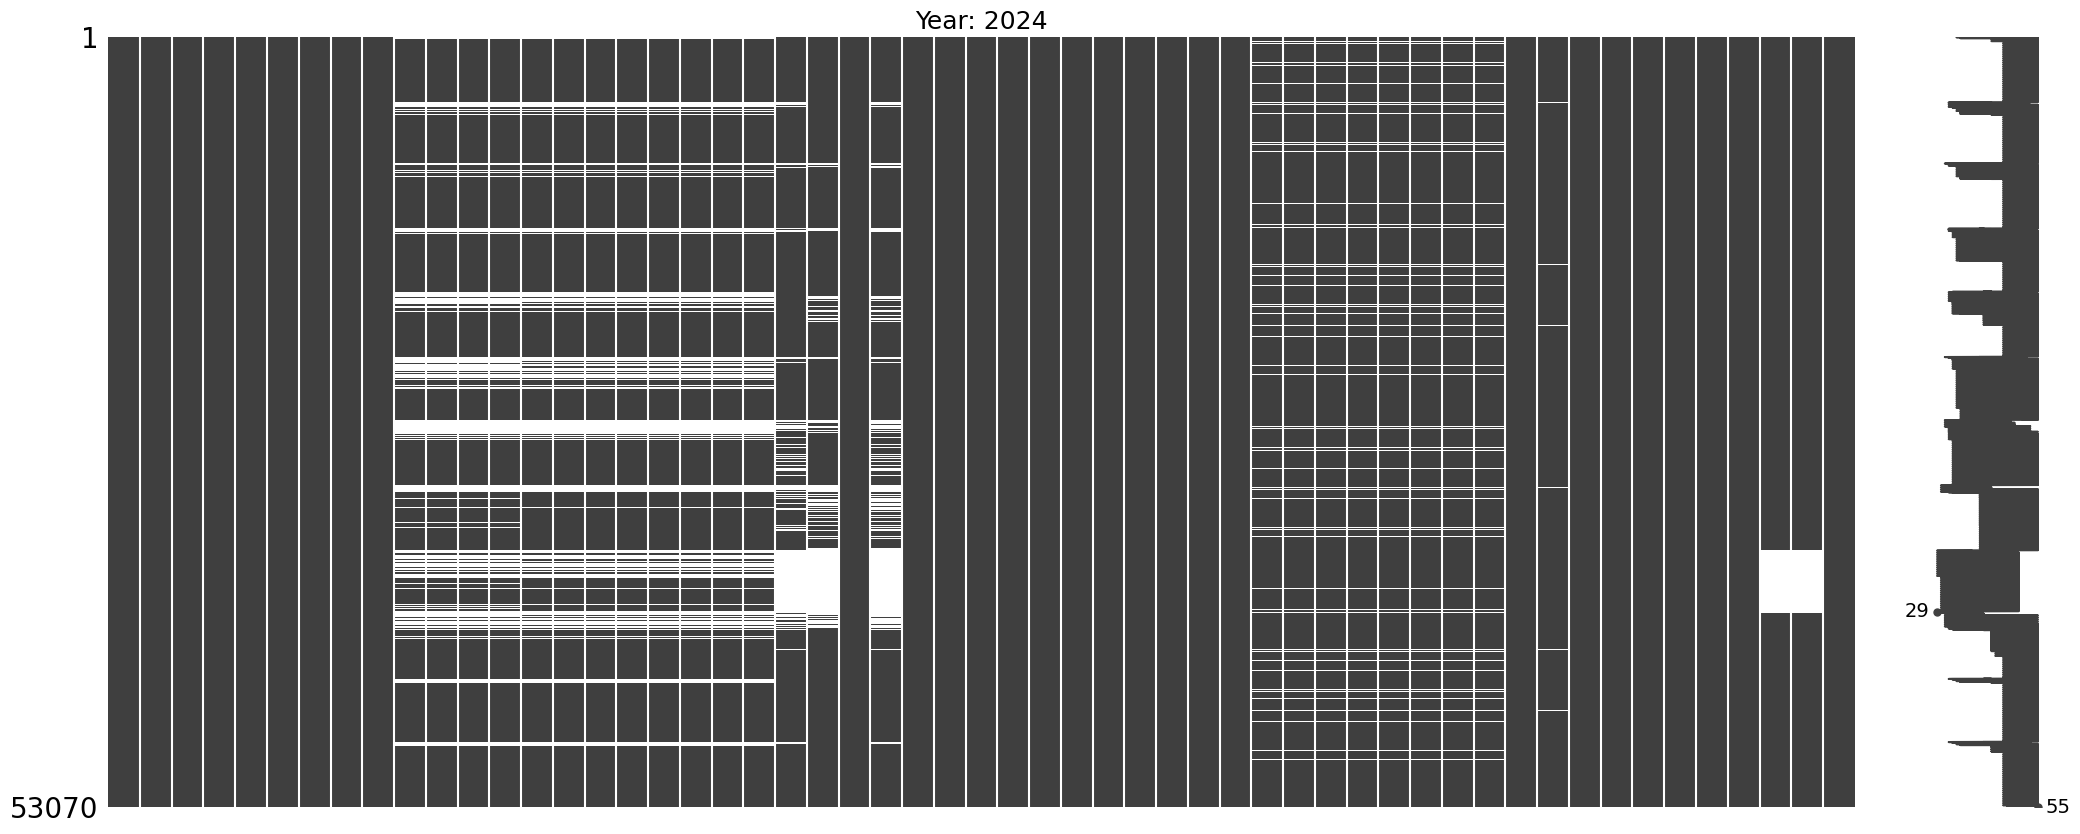

In [45]:
msno.matrix(dataset, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {dataset.year.iloc[0]}", fontsize=18)

In [46]:
dataset.rename(columns={"dt_placement": "dt_placement_daily"}, inplace=True)
dataset['date_string'] = dataset['month'].astype(str) + '-' + dataset['year'].astype(str)
dataset['dt_placement'] = pd.to_datetime(dataset['date_string'], format='%m-%Y').dt.to_period('M')
dataset.drop(columns=['date_string'], inplace = True)

In [47]:
dataset.head()

,dt_placement_daily,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc,dt_placement
0,2024-01-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.850000,18.730000,0.0,27.790000,0.5,0.866,11525.501547,1189.566737,3.200000,176.556138,234.750015,181.293075,0.0,4.122890,2023,2812.420746,750.981640,1.788854,48.896611,24.034117,1.205482,0.0,5.969408,31.0,36.0,30.0,12,12,3,5,8,15.314000,40.866000,0.008000,2024-01
1,2024-01-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.788462,19.585385,0.0,27.686923,0.5,0.866,27643.505181,1357.065997,2.871795,173.781355,293.252756,180.811286,0.0,92.996499,2023,6064.190727,931.673366,1.641236,38.303046,43.861207,1.301525,0.0,459.006647,31.0,36.0,30.0,12,12,3,5,8,16.478205,39.986923,0.695641,2024-01
2,2024-01-01,nord,benoue,bibemi,bide,13.972945,9.422292,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.330000,19.215333,0.0,27.272667,0.5,0.866,22660.822965,1318.020573,2.600000,168.650613,304.317929,180.301336,0.0,93.489080,2023,5555.845612,719.271733,1.242118,31.219410,20.072188,1.639950,0.0,330.447001,31.0,36.0,30.0,12,12,3,5,8,16.536667,39.618000,1.175333,2024-01
3,2024-01-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.713636,18.980909,0.0,26.847273,0.5,0.866,6789.434645,1430.318925,2.181818,167.127816,200.161964,180.523037,0.0,5.106007,2023,4263.616083,736.589253,1.167748,24.830296,14.391049,1.040369,0.0,7.221327,31.0,36.0,30.0,12,12,3,5,8,15.319091,38.633636,0.063636,2024-01
4,2024-01-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.776667,20.723333,0.0,27.750000,0.5,0.866,5443.506799,2018.690644,9.333333,194.838800,332.209587,175.000090,0.0,6.187549,2023,4805.139710,451.444712,9.712535,47.638218,77.268242,7.151423,0.0,7.464223,31.0,36.0,30.0,12,12,3,5,8,17.536667,39.523333,0.323333,2024-01


In [48]:
grouped_by_month = dataset.drop(columns=['dt_placement_daily']).groupby(['dt_placement','GID0','GID1','GID2','GID3'], as_index = False)

In [49]:
grouped_by_month_mean = grouped_by_month.mean()
grouped_by_month_sum = grouped_by_month.sum()

In [50]:
grouped_by_month_mean.head()

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc
0,2024-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2024.0,1.0,0.210098,-0.147509,-0.335927,0.147509,0.211859,-0.151186,-0.347978,0.151186,0.013583,0.021531,0.013390,0.021531,36.912065,17.705871,0.000258,27.308968,0.5,0.866,11525.501547,1189.566737,3.200000,176.556138,234.750015,181.293075,0.0,4.122890,2023.0,2812.420746,750.981640,1.788854,48.896611,24.034117,1.205482,0.0,5.969408,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,15.314000,40.866000,0.008000
1,2024-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2024.0,1.0,0.229805,-0.148718,-0.346496,0.148718,0.227733,-0.150692,-0.346205,0.150692,0.015927,0.016900,0.014961,0.016900,35.939611,18.564938,0.022440,27.252275,0.5,0.866,27643.505181,1357.065997,2.871795,173.781355,293.252756,180.811286,0.0,92.996499,2023.0,6064.190727,931.673366,1.641236,38.303046,43.861207,1.301525,0.0,459.006647,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,16.478205,39.986923,0.695641
2,2024-01,nord,benoue,bibemi,bide,13.972945,9.422292,2024.0,1.0,0.229615,-0.121265,-0.347762,0.121265,0.230149,-0.117264,-0.348967,0.117264,0.015778,0.016250,0.012650,0.016250,35.460065,18.393269,0.037914,26.926667,0.5,0.866,22660.822965,1318.020573,2.600000,168.650613,304.317929,180.301336,0.0,93.489080,2023.0,5555.845612,719.271733,1.242118,31.219410,20.072188,1.639950,0.0,330.447001,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,16.536667,39.618000,1.175333
3,2024-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2024.0,1.0,0.232036,-0.131119,-0.310579,0.131119,0.236233,-0.132011,-0.317560,0.132011,0.021837,0.026530,0.017731,0.026530,35.119267,17.724721,0.002053,26.421994,0.5,0.866,6789.434645,1430.318925,2.181818,167.127816,200.161964,180.523037,0.0,5.106007,2023.0,4263.616083,736.589253,1.167748,24.830296,14.391049,1.040369,0.0,7.221327,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,15.319091,38.633636,0.063636
4,2024-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2024.0,1.0,0.215183,-0.053718,-0.312861,0.053718,0.223605,-0.039268,-0.316439,0.039268,0.036640,0.030206,0.037070,0.030206,34.844409,19.767849,0.010430,27.306129,0.5,0.866,5443.506799,2018.690644,9.333333,194.838800,332.209587,175.000090,0.0,6.187549,2023.0,4805.139710,451.444712,9.712535,47.638218,77.268242,7.151423,0.0,7.464223,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,17.536667,39.523333,0.323333


In [51]:
print(f'Shape of the grouped_by_month_mean file: {grouped_by_month_mean.shape}')

Shape of the grouped_by_month_mean file: (1740, 55)


Text(0.5, 1.0, 'Year: 2024.0')

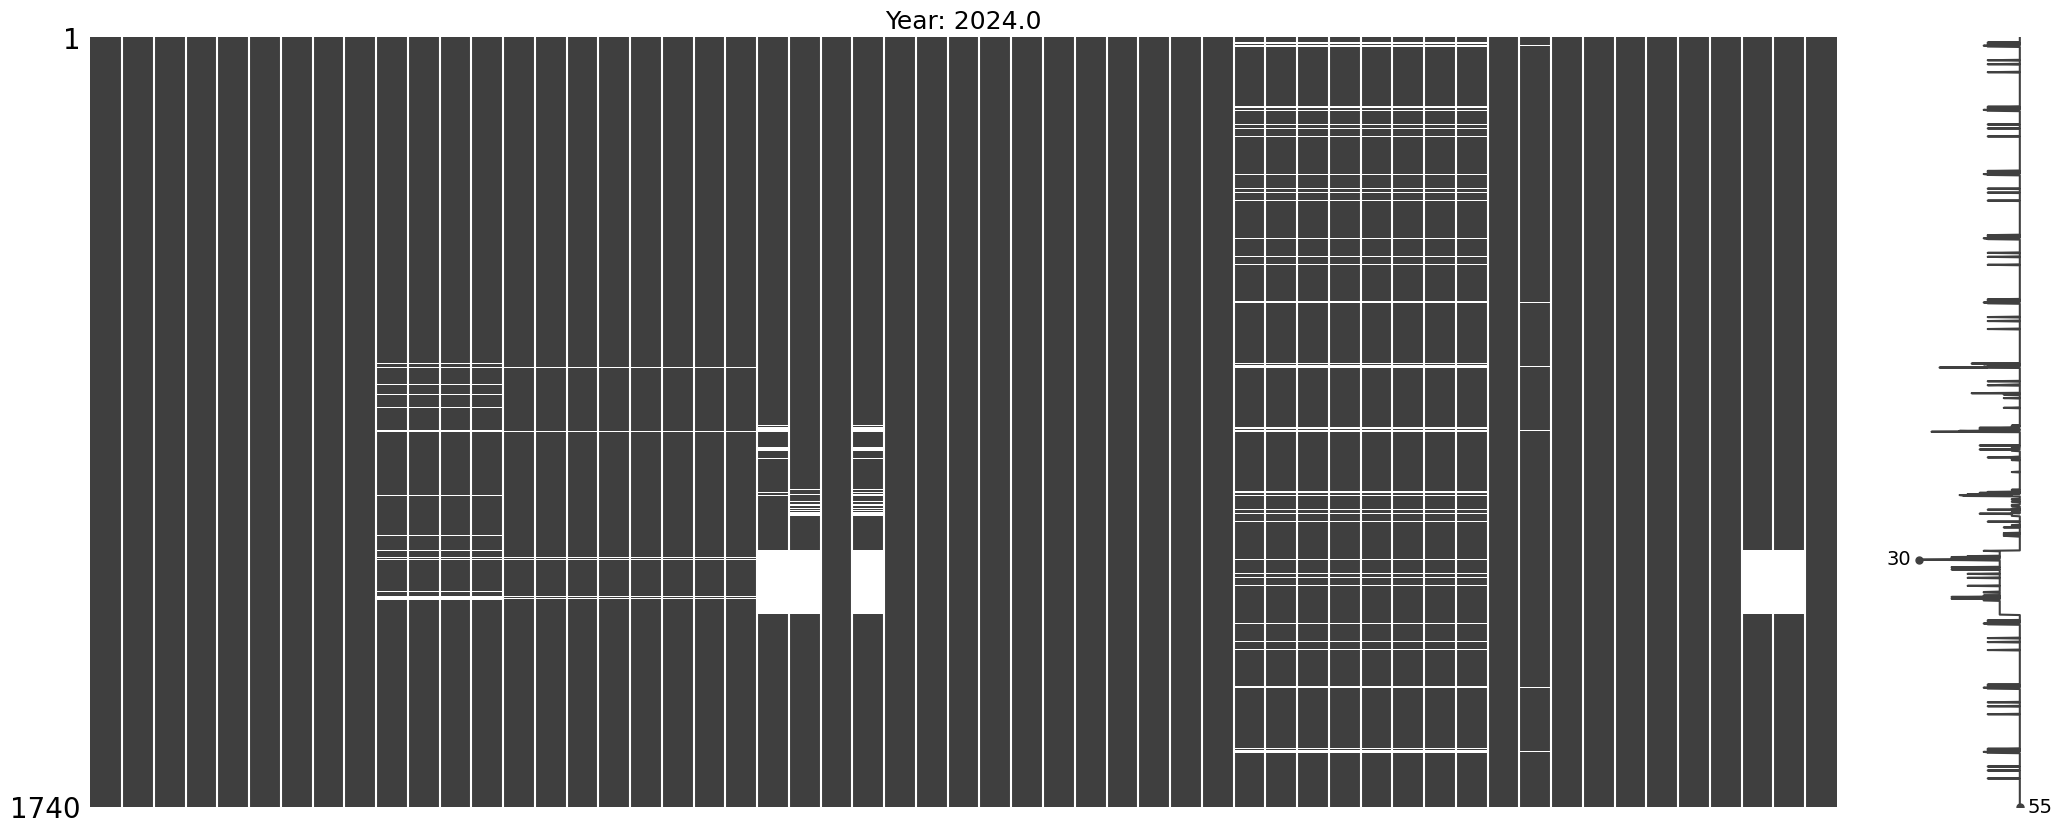

In [52]:
msno.matrix(grouped_by_month_mean, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {grouped_by_month_mean.year.iloc[0]}", fontsize=18)

In [53]:
grouped_by_month_mean

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc
0,2024-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2024.0,1.0,0.210098,-0.147509,-0.335927,0.147509,0.211859,-0.151186,-0.347978,0.151186,0.013583,0.021531,0.013390,0.021531,36.912065,17.705871,0.000258,27.308968,0.5,0.866,11525.501547,1189.566737,3.200000,176.556138,234.750015,181.293075,0.0,4.122890,2023.0,2812.420746,750.981640,1.788854,48.896611,24.034117,1.205482,0.0,5.969408,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,15.314000,40.866000,0.008000
1,2024-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2024.0,1.0,0.229805,-0.148718,-0.346496,0.148718,0.227733,-0.150692,-0.346205,0.150692,0.015927,0.016900,0.014961,0.016900,35.939611,18.564938,0.022440,27.252275,0.5,0.866,27643.505181,1357.065997,2.871795,173.781355,293.252756,180.811286,0.0,92.996499,2023.0,6064.190727,931.673366,1.641236,38.303046,43.861207,1.301525,0.0,459.006647,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,16.478205,39.986923,0.695641
2,2024-01,nord,benoue,bibemi,bide,13.972945,9.422292,2024.0,1.0,0.229615,-0.121265,-0.347762,0.121265,0.230149,-0.117264,-0.348967,0.117264,0.015778,0.016250,0.012650,0.016250,35.460065,18.393269,0.037914,26.926667,0.5,0.866,22660.822965,1318.020573,2.600000,168.650613,304.317929,180.301336,0.0,93.489080,2023.0,5555.845612,719.271733,1.242118,31.219410,20.072188,1.639950,0.0,330.447001,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,16.536667,39.618000,1.175333
3,2024-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2024.0,1.0,0.232036,-0.131119,-0.310579,0.131119,0.236233,-0.132011,-0.317560,0.132011,0.021837,0.026530,0.017731,0.026530,35.119267,17.724721,0.002053,26.421994,0.5,0.866,6789.434645,1430.318925,2.181818,167.127816,200.161964,180.523037,0.0,5.106007,2023.0,4263.616083,736.589253,1.167748,24.830296,14.391049,1.040369,0.0,7.221327,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,15.319091,38.633636,0.063636
4,2024-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2024.0,1.0,0.215183,-0.053718,-0.312861,0.053718,0.223605,-0.039268,-0.316439,0.039268,0.036640,0.030206,0.037070,0.030206,34.844409,19.767849,0.010430,27.306129,0.5,0.866,5443.506799,2018.690644,9.333333,194.838800,332.209587,175.000090,0.0,6.187549,2023.0,4805.139710,451.444712,9.712535,47.638218,77.268242,7.151423,0.0,7.464223,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,17.536667,39.523333,0.323333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1735,2024-12,nord,mayo-rey,touboro,mbeing,15.001895,7.650008,2024.0,12.0,0.404566,0.004045,-0.360921,-0.004045,0.407666,0.007945,-0.362101,-0.007945,0.026467,0.029746,0.018991,0.029746,27.182712,17.098900,0.008580,22.132467,0.0,1.000,125988.493830,1351.464075,5.487179,165.595614,710.625604,180.155729,0.0,416.446254,2023.0,9674.688211,975.207537,6.237561,51.830772,161.275638,6.209749,0.0,3164.666798,22.0,20.0,20.0,9.0,9.0,4.0,4.0,4.0,16.174444,29.880769,0.265983
1736,2024-12,nord,mayo-rey,touboro,ngai-lara,15.110765,7.963850,2024.0,12.0,0.371936,-0.033160,-0.387453,0.033160,0.373239,-0.033772,-0.387843,0.033772,0.027619,0.029370,0.017367,0.029370,29.481552,18.314605,0.000078,23.892592,0.0,1.000,96382.615442,1575.283286,5.603448,162.531613,676.741170,177.469545,0.0,10.120173,2023.0,9407.825255,1053.074968,5.902541,47.841931,166.460795,6.074794,0.0,32.532102,22.0,2

In [54]:
month_mean_unit_counts = []

for gid_unit in grouped_by_month_mean.GID3.sort_values().unique().tolist():
    count = (grouped_by_month_mean['GID3'] == gid_unit).sum()
    month_mean_unit_counts.append({'GID3': gid_unit,
                            'count': count})

month_mean_unit_counts_df = pd.DataFrame(month_mean_unit_counts)

In [55]:
fig = px.bar(month_mean_unit_counts_df, x='GID3', y='count', title='Count per Region')
fig.update_layout(xaxis_title='Region (GID3)', yaxis_title='Count')
fig.show()

In [56]:
grouped_by_month_mean['year'] = grouped_by_month_mean['year'].astype(int)
grouped_by_month_mean['year_lc'] = grouped_by_month_mean['year_lc'].astype(int)
grouped_by_month_mean['month'] = grouped_by_month_mean['month'].astype(int)

In [57]:
grouped_by_month_mean

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc
0,2024-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2024,1,0.210098,-0.147509,-0.335927,0.147509,0.211859,-0.151186,-0.347978,0.151186,0.013583,0.021531,0.013390,0.021531,36.912065,17.705871,0.000258,27.308968,0.5,0.866,11525.501547,1189.566737,3.200000,176.556138,234.750015,181.293075,0.0,4.122890,2023,2812.420746,750.981640,1.788854,48.896611,24.034117,1.205482,0.0,5.969408,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,15.314000,40.866000,0.008000
1,2024-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2024,1,0.229805,-0.148718,-0.346496,0.148718,0.227733,-0.150692,-0.346205,0.150692,0.015927,0.016900,0.014961,0.016900,35.939611,18.564938,0.022440,27.252275,0.5,0.866,27643.505181,1357.065997,2.871795,173.781355,293.252756,180.811286,0.0,92.996499,2023,6064.190727,931.673366,1.641236,38.303046,43.861207,1.301525,0.0,459.006647,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,16.478205,39.986923,0.695641
2,2024-01,nord,benoue,bibemi,bide,13.972945,9.422292,2024,1,0.229615,-0.121265,-0.347762,0.121265,0.230149,-0.117264,-0.348967,0.117264,0.015778,0.016250,0.012650,0.016250,35.460065,18.393269,0.037914,26.926667,0.5,0.866,22660.822965,1318.020573,2.600000,168.650613,304.317929,180.301336,0.0,93.489080,2023,5555.845612,719.271733,1.242118,31.219410,20.072188,1.639950,0.0,330.447001,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,16.536667,39.618000,1.175333
3,2024-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2024,1,0.232036,-0.131119,-0.310579,0.131119,0.236233,-0.132011,-0.317560,0.132011,0.021837,0.026530,0.017731,0.026530,35.119267,17.724721,0.002053,26.421994,0.5,0.866,6789.434645,1430.318925,2.181818,167.127816,200.161964,180.523037,0.0,5.106007,2023,4263.616083,736.589253,1.167748,24.830296,14.391049,1.040369,0.0,7.221327,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,15.319091,38.633636,0.063636
4,2024-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2024,1,0.215183,-0.053718,-0.312861,0.053718,0.223605,-0.039268,-0.316439,0.039268,0.036640,0.030206,0.037070,0.030206,34.844409,19.767849,0.010430,27.306129,0.5,0.866,5443.506799,2018.690644,9.333333,194.838800,332.209587,175.000090,0.0,6.187549,2023,4805.139710,451.444712,9.712535,47.638218,77.268242,7.151423,0.0,7.464223,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,17.536667,39.523333,0.323333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1735,2024-12,nord,mayo-rey,touboro,mbeing,15.001895,7.650008,2024,12,0.404566,0.004045,-0.360921,-0.004045,0.407666,0.007945,-0.362101,-0.007945,0.026467,0.029746,0.018991,0.029746,27.182712,17.098900,0.008580,22.132467,0.0,1.000,125988.493830,1351.464075,5.487179,165.595614,710.625604,180.155729,0.0,416.446254,2023,9674.688211,975.207537,6.237561,51.830772,161.275638,6.209749,0.0,3164.666798,22.0,20.0,20.0,9.0,9.0,4.0,4.0,4.0,16.174444,29.880769,0.265983
1736,2024-12,nord,mayo-rey,touboro,ngai-lara,15.110765,7.963850,2024,12,0.371936,-0.033160,-0.387453,0.033160,0.373239,-0.033772,-0.387843,0.033772,0.027619,0.029370,0.017367,0.029370,29.481552,18.314605,0.000078,23.892592,0.0,1.000,96382.615442,1575.283286,5.603448,162.531613,676.741170,177.469545,0.0,10.120173,2023,9407.825255,1053.074968,5.902541,47.841931,166.460795,6.074794,0.0,32.532102,22.0,20.0,20.0,9.0,9.0,4.0,4.0,4.0,16.697586,32.

In [58]:
grouped_by_month_sum = grouped_by_month_sum[['dt_placement', 'GID0', 'GID1', 'GID2', 'GID3', 'rainfall']].copy()
grouped_by_month_sum.rename(columns={"rainfall": "rainfall_acc"}, inplace=True)

dataset = pd.merge(grouped_by_month_mean, grouped_by_month_sum, on=['dt_placement', 'GID0', 'GID1', 'GID2', 'GID3'], how='left')

In [59]:
dataset.head()

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc,rainfall_acc
0,2024-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2024,1,0.210098,-0.147509,-0.335927,0.147509,0.211859,-0.151186,-0.347978,0.151186,0.013583,0.021531,0.013390,0.021531,36.912065,17.705871,0.000258,27.308968,0.5,0.866,11525.501547,1189.566737,3.200000,176.556138,234.750015,181.293075,0.0,4.122890,2023,2812.420746,750.981640,1.788854,48.896611,24.034117,1.205482,0.0,5.969408,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,15.314000,40.866000,0.008000,0.008000
1,2024-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2024,1,0.229805,-0.148718,-0.346496,0.148718,0.227733,-0.150692,-0.346205,0.150692,0.015927,0.016900,0.014961,0.016900,35.939611,18.564938,0.022440,27.252275,0.5,0.866,27643.505181,1357.065997,2.871795,173.781355,293.252756,180.811286,0.0,92.996499,2023,6064.190727,931.673366,1.641236,38.303046,43.861207,1.301525,0.0,459.006647,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,16.478205,39.986923,0.695641,0.695641
2,2024-01,nord,benoue,bibemi,bide,13.972945,9.422292,2024,1,0.229615,-0.121265,-0.347762,0.121265,0.230149,-0.117264,-0.348967,0.117264,0.015778,0.016250,0.012650,0.016250,35.460065,18.393269,0.037914,26.926667,0.5,0.866,22660.822965,1318.020573,2.600000,168.650613,304.317929,180.301336,0.0,93.489080,2023,5555.845612,719.271733,1.242118,31.219410,20.072188,1.639950,0.0,330.447001,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,16.536667,39.618000,1.175333,1.175333
3,2024-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2024,1,0.232036,-0.131119,-0.310579,0.131119,0.236233,-0.132011,-0.317560,0.132011,0.021837,0.026530,0.017731,0.026530,35.119267,17.724721,0.002053,26.421994,0.5,0.866,6789.434645,1430.318925,2.181818,167.127816,200.161964,180.523037,0.0,5.106007,2023,4263.616083,736.589253,1.167748,24.830296,14.391049,1.040369,0.0,7.221327,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,15.319091,38.633636,0.063636,0.063636
4,2024-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2024,1,0.215183,-0.053718,-0.312861,0.053718,0.223605,-0.039268,-0.316439,0.039268,0.036640,0.030206,0.037070,0.030206,34.844409,19.767849,0.010430,27.306129,0.5,0.866,5443.506799,2018.690644,9.333333,194.838800,332.209587,175.000090,0.0,6.187549,2023,4805.139710,451.444712,9.712535,47.638218,77.268242,7.151423,0.0,7.464223,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,17.536667,39.523333,0.323333,0.323333


In [60]:
cols_to_impute = ['monthly_lst_min', 'monthly_lst_max', 'monthly_rainfall_acc']

imputer = IterativeImputer(random_state=0)

dataset[cols_to_impute] = imputer.fit_transform(dataset[cols_to_impute])

In [61]:
dataset['location'] = list(zip(dataset['GID2'], dataset['GID3']))
grouped = dataset.groupby(['year', 'location'])
bio_var_names = [f'bio{i}' for i in range(1, 20)]

# Store results
biovars = []

# Iterate over groups
for (year, location), group in grouped:
    tmin = robjects.IntVector(group['monthly_lst_min'].tolist())
    tmax = robjects.IntVector(group['monthly_lst_max'].tolist())
    prec = robjects.IntVector(group['monthly_rainfall_acc'].tolist())

    # Call the R function
    bio_values = list(dismo.biovars(prec, tmin, tmax))

    # Construct the result dict dynamically
    result = {
        'year': year,
        'location': location,
        **dict(zip(bio_var_names, bio_values))
    }
    biovars.append(result)

# Convert to DataFrame
biovars_df = pd.DataFrame(biovars)

In [62]:
# if dismo.biovars fails

biovars_df.replace(-2147483648, np.nan, inplace=True)

In [63]:
biovars_df

,year,location,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2024,"(bibemi, adoumri)",28.333333,16.833333,56.111111,342.672208,45.0,15.0,30.0,25.333333,26.666667,33.500000,25.333333,1724.0,356.0,0.0,109.477715,1043.0,0.0,131.0,1043.0
1,2024,"(bibemi, bibemi)",28.583333,16.500000,56.896552,334.958161,45.0,16.0,29.0,25.666667,26.833333,33.500000,25.666667,1706.0,380.0,0.0,111.289300,1061.0,1.0,121.0,1061.0
2,2024,"(bibemi, bide)",28.625000,17.416667,60.057471,328.304875,45.0,16.0,29.0,26.166667,26.500000,33.500000,26.166667,1639.0,407.0,0.0,115.459455,1054.0,5.0,98.0,1054.0
3,2024,"(bibemi, dengui)",28.375000,17.083333,58.908046,292.423261,44.0,15.0,29.0,27.000000,26.333333,33.000000,26.000000,1842.0,376.0,0.0,107.778696,1102.0,2.0,152.0,265.0
4,2024,"(bibemi, djaloumi)",28.916667,17.500000,62.500000,319.682608,45.0,17.0,28.0,26.500000,27.333333,33.833333,26.333333,1816.0,501.0,0.0,123.139104,1245.0,2.0,85.0,1229.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140,2024,"(touboro, mbeing)",25.375000,13.416667,49.691358,322.014257,41.0,14.0,27.0,22.833333,22.833333,29.833333,22.833333,2887.0,796.0,0.0,111.358527,1749.0,0.0,288.0,1749.0
141,2024,"(touboro, ngai-lara)",26.583333,15.000000,53.571429,335.635986,44.0,16.0,28.0,23.666667,24.666667,31.166667,23.666667,2647.0,795.0,0.0,118.214015,1678.0,0.0,114.0,1678.0
142,2024,"(touboro, touboro)",26.708333,15.416667,55.059524,368.324421,43.0,15.0,28.0,25.000000,24.166667,32.166667,23.833333,2850.0,833.0,0.0,116.114483,1796.0,0.0,249.0,1780.0
143,2024,"(touboro, vogzom)",25.875000,14.916667,51.436782,345.177820,43.0,14.0,29.0,23.500000,23.166667,31.000000,23.000000,2877.0,766.0,0.0,109.006321,1708.0,0.0,305.0,432.0


In [64]:
dataset = pd.merge(dataset, biovars_df,  how='left', on=['location', 'year'])

dataset.drop(columns=['location'], inplace=True)
dataset.reset_index(drop=True, inplace=True)

In [65]:
dataset

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc,rainfall_acc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2024-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2024,1,0.210098,-0.147509,-0.335927,0.147509,0.211859,-0.151186,-0.347978,0.151186,0.013583,0.021531,0.013390,0.021531,36.912065,17.705871,0.000258,27.308968,0.5,0.866,11525.501547,1189.566737,3.200000,176.556138,234.750015,181.293075,0.0,4.122890,2023,2812.420746,750.981640,1.788854,48.896611,24.034117,1.205482,0.0,5.969408,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,15.314000,40.866000,0.008000,0.008000,28.333333,16.833333,56.111111,342.672208,45.0,15.0,30.0,25.333333,26.666667,33.500000,25.333333,1724.0,356.0,0.0,109.477715,1043.0,0.0,131.0,1043.0
1,2024-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2024,1,0.229805,-0.148718,-0.346496,0.148718,0.227733,-0.150692,-0.346205,0.150692,0.015927,0.016900,0.014961,0.016900,35.939611,18.564938,0.022440,27.252275,0.5,0.866,27643.505181,1357.065997,2.871795,173.781355,293.252756,180.811286,0.0,92.996499,2023,6064.190727,931.673366,1.641236,38.303046,43.861207,1.301525,0.0,459.006647,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,16.478205,39.986923,0.695641,0.695641,28.583333,16.500000,56.896552,334.958161,45.0,16.0,29.0,25.666667,26.833333,33.500000,25.666667,1706.0,380.0,0.0,111.289300,1061.0,1.0,121.0,1061.0
2,2024-01,nord,benoue,bibemi,bide,13.972945,9.422292,2024,1,0.229615,-0.121265,-0.347762,0.121265,0.230149,-0.117264,-0.348967,0.117264,0.015778,0.016250,0.012650,0.016250,35.460065,18.393269,0.037914,26.926667,0.5,0.866,22660.822965,1318.020573,2.600000,168.650613,304.317929,180.301336,0.0,93.489080,2023,5555.845612,719.271733,1.242118,31.219410,20.072188,1.639950,0.0,330.447001,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,16.536667,39.618000,1.175333,1.175333,28.625000,17.416667,60.057471,328.304875,45.0,16.0,29.0,26.166667,26.500000,33.500000,26.166667,1639.0,407.0,0.0,115.459455,1054.0,5.0,98.0,1054.0
3,2024-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2024,1,0.232036,-0.131119,-0.310579,0.131119,0.236233,-0.132011,-0.317560,0.132011,0.021837,0.026530,0.017731,0.026530,35.119267,17.724721,0.002053,26.421994,0.5,0.866,6789.434645,1430.318925,2.181818,167.127816,200.161964,180.523037,0.0,5.106007,2023,4263.616083,736.589253,1.167748,24.830296,14.391049,1.040369,0.0,7.221327,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,15.319091,38.633636,0.063636,0.063636,28.375000,17.083333,58.908046,292.423261,44.0,15.0,29.0,27.000000,26.333333,33.000000,26.000000,1842.0,376.0,0.0,107.778696,1102.0,2.0,152.0,265.0
4,2024-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2024,1,0.215183,-0.053718,-0.312861,0.053718,0.223605,-0.039268,-0.316439,0.039268,0.036640,0.030206,0.037070,0.030206,34.844409,19.767849,0.010430,27.306129,0.5,0.866,5443.506799,2018.690644,9.333333,194.838800,332.209587,175.000090,0.0,6.187549,2023,4805.139710,451.444712,9.712535,47.638218,77.268242,7.151423,0.0,7.464223,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,17.536667,39.523333,0.323333,0.323333,28.916667,17.500000,62.500000,319.682608,45.0,17.0,28.0,26.500000,27.333333,33.833333,26.333333,1816.0,501.0,0.0,123.139104,1245.0,2.0,85.0,1229.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,

Text(0.5, 1.0, 'Year: 2024')

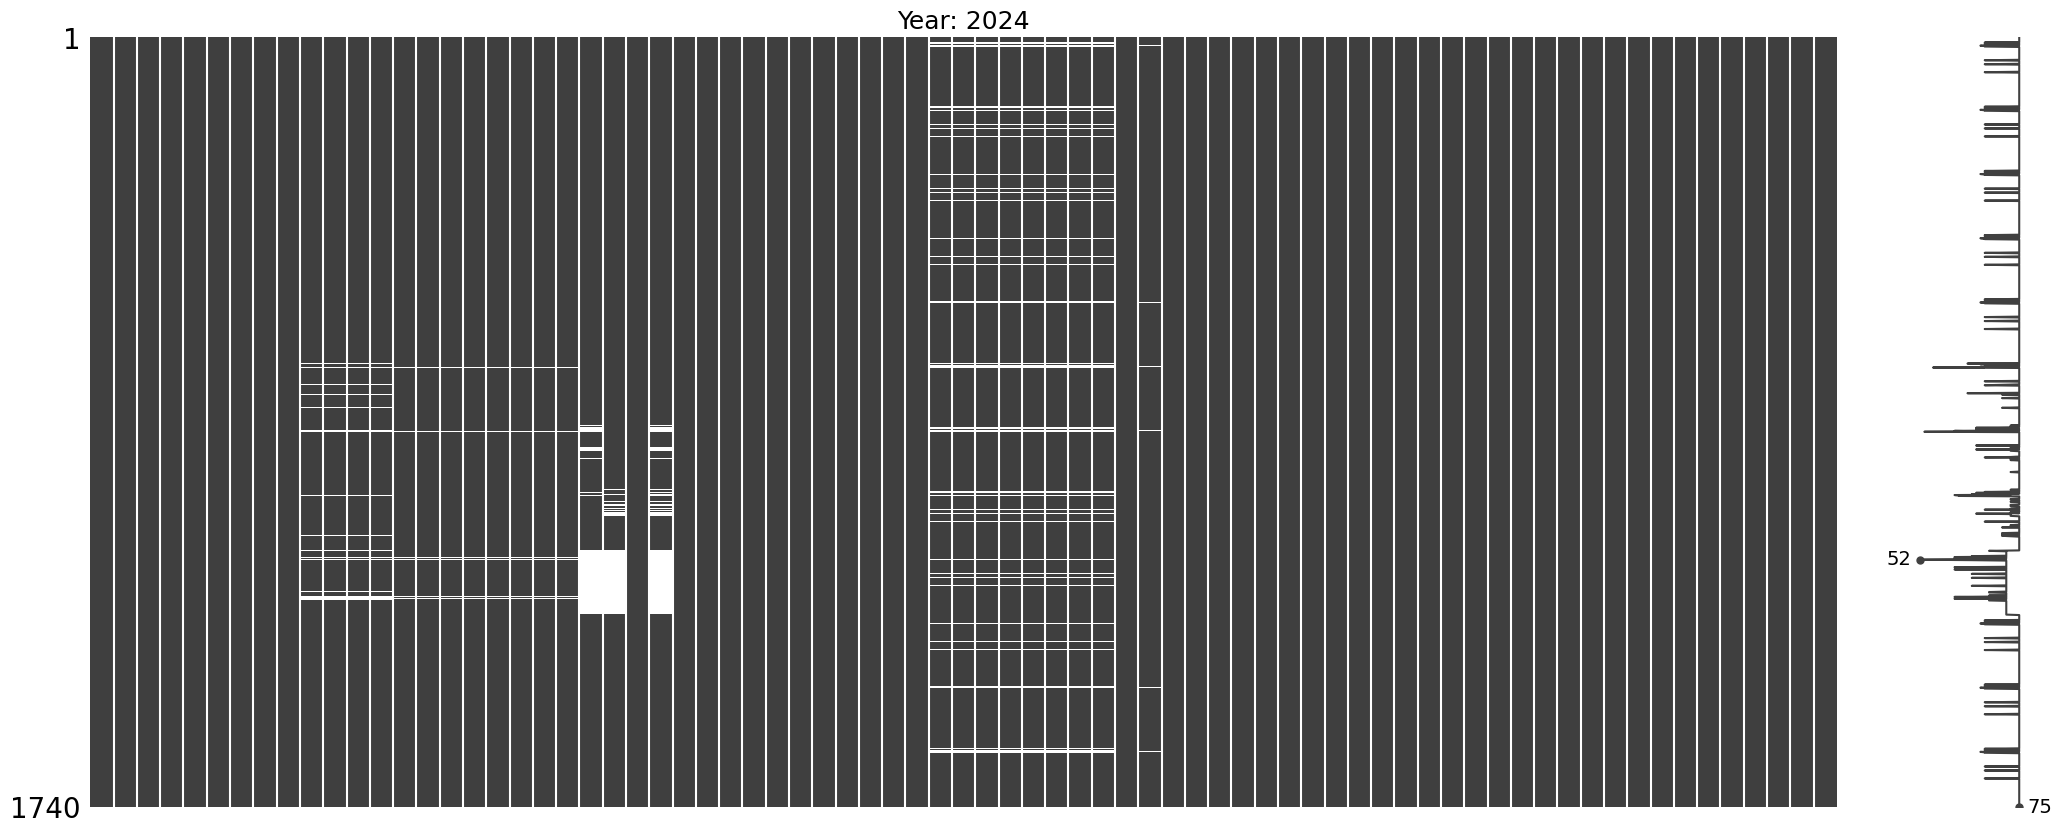

In [66]:
msno.matrix(dataset, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {dataset.year.iloc[0]}", fontsize=18)

In [67]:
dataset

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc,rainfall_acc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2024-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2024,1,0.210098,-0.147509,-0.335927,0.147509,0.211859,-0.151186,-0.347978,0.151186,0.013583,0.021531,0.013390,0.021531,36.912065,17.705871,0.000258,27.308968,0.5,0.866,11525.501547,1189.566737,3.200000,176.556138,234.750015,181.293075,0.0,4.122890,2023,2812.420746,750.981640,1.788854,48.896611,24.034117,1.205482,0.0,5.969408,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,15.314000,40.866000,0.008000,0.008000,28.333333,16.833333,56.111111,342.672208,45.0,15.0,30.0,25.333333,26.666667,33.500000,25.333333,1724.0,356.0,0.0,109.477715,1043.0,0.0,131.0,1043.0
1,2024-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2024,1,0.229805,-0.148718,-0.346496,0.148718,0.227733,-0.150692,-0.346205,0.150692,0.015927,0.016900,0.014961,0.016900,35.939611,18.564938,0.022440,27.252275,0.5,0.866,27643.505181,1357.065997,2.871795,173.781355,293.252756,180.811286,0.0,92.996499,2023,6064.190727,931.673366,1.641236,38.303046,43.861207,1.301525,0.0,459.006647,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,16.478205,39.986923,0.695641,0.695641,28.583333,16.500000,56.896552,334.958161,45.0,16.0,29.0,25.666667,26.833333,33.500000,25.666667,1706.0,380.0,0.0,111.289300,1061.0,1.0,121.0,1061.0
2,2024-01,nord,benoue,bibemi,bide,13.972945,9.422292,2024,1,0.229615,-0.121265,-0.347762,0.121265,0.230149,-0.117264,-0.348967,0.117264,0.015778,0.016250,0.012650,0.016250,35.460065,18.393269,0.037914,26.926667,0.5,0.866,22660.822965,1318.020573,2.600000,168.650613,304.317929,180.301336,0.0,93.489080,2023,5555.845612,719.271733,1.242118,31.219410,20.072188,1.639950,0.0,330.447001,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,16.536667,39.618000,1.175333,1.175333,28.625000,17.416667,60.057471,328.304875,45.0,16.0,29.0,26.166667,26.500000,33.500000,26.166667,1639.0,407.0,0.0,115.459455,1054.0,5.0,98.0,1054.0
3,2024-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2024,1,0.232036,-0.131119,-0.310579,0.131119,0.236233,-0.132011,-0.317560,0.132011,0.021837,0.026530,0.017731,0.026530,35.119267,17.724721,0.002053,26.421994,0.5,0.866,6789.434645,1430.318925,2.181818,167.127816,200.161964,180.523037,0.0,5.106007,2023,4263.616083,736.589253,1.167748,24.830296,14.391049,1.040369,0.0,7.221327,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,15.319091,38.633636,0.063636,0.063636,28.375000,17.083333,58.908046,292.423261,44.0,15.0,29.0,27.000000,26.333333,33.000000,26.000000,1842.0,376.0,0.0,107.778696,1102.0,2.0,152.0,265.0
4,2024-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2024,1,0.215183,-0.053718,-0.312861,0.053718,0.223605,-0.039268,-0.316439,0.039268,0.036640,0.030206,0.037070,0.030206,34.844409,19.767849,0.010430,27.306129,0.5,0.866,5443.506799,2018.690644,9.333333,194.838800,332.209587,175.000090,0.0,6.187549,2023,4805.139710,451.444712,9.712535,47.638218,77.268242,7.151423,0.0,7.464223,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,17.536667,39.523333,0.323333,0.323333,28.916667,17.500000,62.500000,319.682608,45.0,17.0,28.0,26.500000,27.333333,33.833333,26.333333,1816.0,501.0,0.0,123.139104,1245.0,2.0,85.0,1229.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,

In [68]:
dataset[dataset.select_dtypes(include='float').columns] = dataset.select_dtypes(include='float').round(6)

rainfall_cols = [col for col in dataset.columns if 'rainfall' in col]
dataset[rainfall_cols] = dataset[rainfall_cols].round(4)

lst_cols = [col for col in dataset.columns if 'lst' in col]
dataset[lst_cols] = dataset[lst_cols].round(2)

bio_cols = [col for col in dataset.columns if 'bio' in col]
dataset[bio_cols] = dataset[bio_cols].round(2)

geo_cols += [f"{col}_std" for col in geo_cols]
dataset[geo_cols] = dataset[geo_cols].round(2)

dataset[mode_cols] = dataset[mode_cols].apply(pd.to_numeric, errors='coerce').astype('Int64')

In [69]:
dataset.shape

(1740, 75)

In [70]:
new_order = ['dt_placement',
             'year',
             'month',
             'year_lc',
             'month_sin',
             'month_cos',
             'GID0',
             'GID1',
             'GID2',
             'GID3',
             'x',
             'y',
             'ndvi',
             'ndmi',
             'ndwi',
             'ndbi',
             'ndvi_mean',
             'ndmi_mean',
             'ndwi_mean',
             'ndbi_mean',
             'ndvi_std',
             'ndmi_std',
             'ndwi_std',
             'ndbi_std',
             'lst',
             'lst_day',
             'lst_night',
             'monthly_lst_min',
             'monthly_lst_max',
             'rainfall',
             'rainfall_acc',
             'monthly_rainfall_acc',
             'distance_to_coast', 
             'distance_to_river', 
             'slope_mean_1km',
             'aspect_mean_200m', 
             'elevation_mean_1km', 
             'hillshade_mean_1km',
             'fs_area_1km', 
             'flow_accu_200m', 
             'distance_to_coast_std',
             'distance_to_river_std', 
             'slope_mean_1km_std', 
             'aspect_mean_200m_std',
             'elevation_mean_1km_std', 
             'hillshade_mean_1km_std', 
             'fs_area_1km_std',
             'flow_accu_200m_std', 
             'lc_prop1', 
             'lc_prop2', 
             'lc_prop3', 
             'lc_type1',
             'lc_type2', 
             'lc_type3', 
             'lc_type4', 
             'lc_type5',
             'bio1',
             'bio2',
             'bio3',
             'bio4',
             'bio5',
             'bio6',
             'bio7',
             'bio8',
             'bio9',
             'bio10',
             'bio11',
             'bio12',
             'bio13',
             'bio14',
             'bio15',
             'bio16',
             'bio17',
             'bio18',
             'bio19']

In [71]:
dataset = dataset[new_order]

In [72]:
dataset.head()

,dt_placement,year,month,year_lc,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,rainfall,rainfall_acc,monthly_rainfall_acc,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2024-01,2024,1,2023,0.5,0.866,nord,benoue,bibemi,adoumri,13.770202,9.240232,0.210098,-0.147509,-0.335927,0.147509,0.211859,-0.151186,-0.347978,0.151186,0.013583,0.021531,0.013390,0.021531,27.31,36.91,17.71,15.31,40.87,0.0003,0.0080,0.0080,11525.50,1189.57,3.20,176.56,234.75,181.29,0.0,4.12,2812.42,750.98,1.79,48.90,24.03,1.21,0.0,5.97,31,36,30,12,12,3,5,8,28.33,16.83,56.11,342.67,45.0,15.0,30.0,25.33,26.67,33.50,25.33,1724.0,356.0,0.0,109.48,1043.0,0.0,131.0,1043.0
1,2024-01,2024,1,2023,0.5,0.866,nord,benoue,bibemi,bibemi,13.949181,9.263633,0.229805,-0.148718,-0.346496,0.148718,0.227733,-0.150692,-0.346205,0.150692,0.015927,0.016900,0.014961,0.016900,27.25,35.94,18.56,16.48,39.99,0.0224,0.6956,0.6956,27643.51,1357.07,2.87,173.78,293.25,180.81,0.0,93.00,6064.19,931.67,1.64,38.30,43.86,1.30,0.0,459.01,31,36,30,12,12,3,5,8,28.58,16.50,56.90,334.96,45.0,16.0,29.0,25.67,26.83,33.50,25.67,1706.0,380.0,0.0,111.29,1061.0,1.0,121.0,1061.0
2,2024-01,2024,1,2023,0.5,0.866,nord,benoue,bibemi,bide,13.972945,9.422292,0.229615,-0.121265,-0.347762,0.121265,0.230149,-0.117264,-0.348967,0.117264,0.015778,0.016250,0.012650,0.016250,26.93,35.46,18.39,16.54,39.62,0.0379,1.1753,1.1753,22660.82,1318.02,2.60,168.65,304.32,180.30,0.0,93.49,5555.85,719.27,1.24,31.22,20.07,1.64,0.0,330.45,31,36,30,12,12,3,5,8,28.62,17.42,60.06,328.30,45.0,16.0,29.0,26.17,26.50,33.50,26.17,1639.0,407.0,0.0,115.46,1054.0,5.0,98.0,1054.0
3,2024-01,2024,1,2023,0.5,0.866,nord,benoue,bibemi,dengui,13.642496,9.235656,0.232036,-0.131119,-0.310579,0.131119,0.236233,-0.132011,-0.317560,0.132011,0.021837,0.026530,0.017731,0.026530,26.42,35.12,17.72,15.32,38.63,0.0021,0.0636,0.0636,6789.43,1430.32,2.18,167.13,200.16,180.52,0.0,5.11,4263.62,736.59,1.17,24.83,14.39,1.04,0.0,7.22,31,36,30,12,12,3,5,8,28.38,17.08,58.91,292.42,44.0,15.0,29.0,27.00,26.33,33.00,26.00,1842.0,376.0,0.0,107.78,1102.0,2.0,152.0,265.0
4,2024-01,2024,1,2023,0.5,0.866,nord,benoue,bibemi,djaloumi,13.994667,9.585190,0.215183,-0.053718,-0.312861,0.053718,0.223605,-0.039268,-0.316439,0.039268,0.036640,0.030206,0.037070,0.030206,27.31,34.84,19.77,17.54,39.52,0.0104,0.3233,0.3233,5443.51,2018.69,9.33,194.84,332.21,175.00,0.0,6.19,4805.14,451.44,9.71,47.64,77.27,7.15,0.0,7.46,31,36,30,12,12,3,5,8,28.92,17.50,62.50,319.68,45.0,17.0,28.0,26.50,27.33,33.83,26.33,1816.0,501.0,0.0,123.14,1245.0,2.0,85.0,1229.0


In [73]:
dataset.shape

(1740, 75)

In [74]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1740 entries, 0 to 1739
Data columns (total 75 columns):
 #   Column                  Non-Null Count  Dtype    
---  ------                  --------------  -----    
 0   dt_placement            1740 non-null   period[M]
 1   year                    1740 non-null   int32    
 2   month                   1740 non-null   int32    
 3   year_lc                 1740 non-null   int32    
 4   month_sin               1740 non-null   float64  
 5   month_cos               1740 non-null   float64  
 6   GID0                    1740 non-null   object   
 7   GID1                    1740 non-null   object   
 8   GID2                    1740 non-null   object   
 9   GID3                    1740 non-null   object   
 10  x                       1740 non-null   float64  
 11  y                       1740 non-null   float64  
 12  ndvi                    1708 non-null   float64  
 13  ndmi                    1708 non-null   float64  
 14  ndwi    

In [76]:
dataset.to_csv(f'../../data/{REGION}/CM_{REGION}_Timeline_{YEAR}_grouped.csv', index=False, encoding=enc)

In [77]:
#dataset.to_csv(f'../../data/{REGION}/CM_{REGION}_Timeline_{YEAR}_08_grouped.csv', index=False, encoding=enc)